In [23]:
import pandas as pd
import yfinance as yf

# =========================
# Import ARTY ETF Prices
# =========================
start = pd.Timestamp("2024-04-01").date()
end = pd.Timestamp("2026-01-01").date()


def fetch_one(symbols, start, end):
    """Try a list of symbols; return the first non-empty Close series (tz-naive)."""
    for s in symbols:
        try:
            df = yf.download(
                s,
                start=start,
                end=end,
                auto_adjust=True,
                progress=False,
                threads=False,
            )
            if isinstance(df, pd.DataFrame) and "Close" in df and not df["Close"].dropna().empty:
                sr = df["Close"].dropna().copy()
                sr.index = pd.to_datetime(sr.index).tz_localize(None)
                sr.name = s
                return sr
        except Exception:
            pass
    return pd.Series(dtype=float)


# ARTY ETF (with optional fallback symbols)
arty_etf = fetch_one(["ARTY"], start, end)
arty_etf.name = "ARTY_ETF"

# Assemble prices
df_etf = pd.concat([arty_etf], axis=1).dropna(how="all")

print("ARTY ETF Prices:")
display(df_etf.tail())

ARTY ETF Prices:


Ticker,ARTY
Date,
2025-12-24,48.509998
2025-12-26,48.610001
2025-12-29,48.619999
2025-12-30,48.669998
2025-12-31,48.180000


# AGI Timeline Forecast: Predictive Analysis with ARTY Factor Decomposition

**Objective:** Forecast AGI timeline shifts using ARTY ETF idiosyncratic returns as a predictive signal.

## Overall Structure:
- **Part A:** Data Acquisition & Factor Decomposition (cells 1-5)
- **Part B:** Structural Analysis & Cross-Market Validation (cells with signed SVAR)
- **Part C:** Exploratory Data Analysis & Time Series (cells 6-9)
- **Part D:** Model Selection & Backtesting (cells 10-13)
- **Part E:** Predictive Simulation & Scenario Analysis (cells 14-17)
- **Part F:** Position Sizing & Risk Management (cells 18-19)

In [24]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.linear_model import HuberRegressor

# ====================================================
# Factor model for ARTY idiosyncratic return (PCA)
# Factors: US tech (^NDX), global equity (ACWI), rates (^TNX)
# Training-window-only estimation to prevent look-ahead bias.
# ====================================================

factor_symbols = ["^NDX", "ACWI", "^TNX"]

factor_prices = yf.download(
    factor_symbols,
    start=start,
    end=end,
    auto_adjust=True,
    progress=False,
    threads=False,
)["Close"]

if isinstance(factor_prices.columns, pd.MultiIndex):
    factor_prices = factor_prices.copy()
    factor_prices.columns = factor_prices.columns.get_level_values(-1)

factor_prices.index = pd.to_datetime(factor_prices.index).tz_localize(None)

# Detect ARTY price column robustly
arty_col = "ARTY" if "ARTY" in df_etf.columns else ("ARTY_ETF" if "ARTY_ETF" in df_etf.columns else df_etf.columns[0])

# Build return panel (rates use level changes; equities use log returns)
ret_df = pd.DataFrame(index=df_etf.index)
ret_df["ARTY"] = np.log(df_etf[arty_col]).diff()
ret_df["^NDX"] = np.log(factor_prices["^NDX"]).diff()
ret_df["ACWI"] = np.log(factor_prices["ACWI"]).diff()
ret_df["^TNX"] = factor_prices["^TNX"].diff()

ret_df = ret_df.dropna().copy()

# PCA on standardized X factors
x_cols = ["^NDX", "ACWI", "^TNX"]

# Training-window-only: use first 80% of data (at least 30 obs) to prevent look-ahead bias
n_total_fm = len(ret_df)
n_train_fm = max(30, n_total_fm - 20)
ret_train = ret_df.iloc[:n_train_fm]
print(f"Factor model sample size: {n_total_fm} total, {n_train_fm} in training window")

# Standardize using training statistics only
X_raw_train = ret_train[x_cols].copy()
X_mean = X_raw_train.mean(axis=0)
X_std = X_raw_train.std(axis=0, ddof=0).replace(0, np.nan)
Xz_train = ((X_raw_train - X_mean) / X_std).dropna().copy()

# Align y to training PCA sample
y_train_fm = ret_train.loc[Xz_train.index, "ARTY"].copy()

# SVD-based PCA on training data only
U, S, Vt = np.linalg.svd(Xz_train.to_numpy(dtype=float), full_matrices=False)
scores_train = U * S
explained_var_ratio = (S**2) / np.sum(S**2)
cum_explained = np.cumsum(explained_var_ratio)

# Keep minimum PCs reaching 95% explained variance (at least 1)
n_components = max(1, int(np.searchsorted(cum_explained, 0.95) + 1))
pc_cols = [f"PC{i+1}" for i in range(n_components)]
X_pca_train = pd.DataFrame(scores_train[:, :n_components], index=Xz_train.index, columns=pc_cols)

# Huber robust regression fitted on training window only
huber = HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=2000)
huber.fit(X_pca_train.to_numpy(), y_train_fm.to_numpy())

# Apply fixed PCA loadings (Vt from training SVD) to full sample — no leakage
X_raw_all = ret_df[x_cols].copy()
Xz_all = (X_raw_all - X_mean) / X_std
Xz_all = Xz_all.dropna()
scores_all = Xz_all.to_numpy(dtype=float) @ Vt[:n_components].T
X_pca_all = pd.DataFrame(scores_all, index=Xz_all.index, columns=pc_cols)

pc_loadings = pd.Series(huber.coef_, index=pc_cols, name="loading")
y_fitted_all = huber.predict(X_pca_all.to_numpy())
y_all = ret_df.loc[X_pca_all.index, "ARTY"].copy()
ret_df.loc[X_pca_all.index, "ARTY_fitted"] = y_fitted_all
ret_df.loc[X_pca_all.index, "ARTY_idiosyncratic"] = y_all.to_numpy() - y_fitted_all

df_etf.loc[X_pca_all.index, "ARTY_fitted"] = y_fitted_all
df_etf.loc[X_pca_all.index, "ARTY_idiosyncratic"] = y_all.to_numpy() - y_fitted_all

factor_model_state = {
    "estimator": "HuberRegressor",
    "estimator_params": {"epsilon": 1.35, "alpha": 1e-4},
    "n_components": n_components,
    "explained_variance_ratio": explained_var_ratio.tolist(),
    "cumulative_explained_variance": cum_explained.tolist(),
    "pc_loadings": pc_loadings.to_dict(),
    "training_window": n_train_fm,
    "leakage_free": True,
}

print("Factor symbols:", factor_symbols)
print("Selected PCA components:", n_components)
print("Explained variance ratio:")
display(pd.Series(explained_var_ratio, index=["PC1", "PC2", "PC3"]).to_frame("ratio"))
print(f"Huber intercept (daily): {huber.intercept_:.6f}")
display(pc_loadings.to_frame())
display(ret_df[["ARTY", "ARTY_fitted", "ARTY_idiosyncratic"]].dropna().tail())

Factor model sample size: 440 total, 420 in training window
Factor symbols: ['^NDX', 'ACWI', '^TNX']
Selected PCA components: 2
Explained variance ratio:


,ratio
PC1,0.651830
PC2,0.327984
PC3,0.020187


Huber intercept (daily): 0.000826


,loading
PC1,0.011596
PC2,-0.000818


,ARTY,ARTY_fitted,ARTY_idiosyncratic
Date,,,
2025-12-24,0.003924,0.002359,0.001566
2025-12-26,0.002059,0.000658,0.001401
2025-12-29,0.000206,-0.006150,0.006356
2025-12-30,0.001028,-0.001440,0.002468
2025-12-31,-0.010119,-0.010118,-0.000001


In [25]:
# E-1: Factor Model Residual Diagnostics
# Verify Huber regression fit quality and idiosyncratic signal properties

if "y_fitted" in globals() and "y" in globals():
    huber_residuals = (y - y_fitted).dropna()
    import scipy.stats
    huber_diagnostics = pd.DataFrame({
        "metric": [
            "Mean idiosyncratic return",
            "Std idiosyncratic return",
            "Skewness",
            "Kurtosis",
            "Min/Max ratio"
        ],
        "value": [
            float(huber_residuals.mean()),
            float(huber_residuals.std()),
            float(huber_residuals.skew()),
            float(huber_residuals.kurtosis()),
            float(abs(huber_residuals.min()) / (abs(huber_residuals.max()) + 1e-10))
        ]
    })
    print("Factor model residual diagnostics:")
    display(huber_diagnostics)
    
    # Residual autocorrelation check
    from statsmodels.graphics.tsaplots import acf
    acf_vals = acf(huber_residuals, nlags=5, fft=False)
    print(f"\nResidual ACF (lags 0-5): {[f'{v:.4f}' for v in acf_vals]}")
else:
    print("Skipping E-1: y or y_fitted not available. Run factor model cell first.")

Factor model residual diagnostics:


,metric,value
0,Mean idiosyncratic return,-0.000044
1,Std idiosyncratic return,0.008068
2,Skewness,-0.759493
3,Kurtosis,6.140813
4,Min/Max ratio,2.344303



Residual ACF (lags 0-5): ['1.0000', '0.0042', '0.0540', '-0.0657', '-0.0178', '0.0141']


In [26]:
import pandas as pd
from pathlib import Path

csv_path = Path("Case Studies/agi-timeline-forecasts.csv")
if not csv_path.exists():
    csv_path = Path("agi-timeline-forecasts.csv")

df_agi_timeline_forecasts = pd.read_csv(csv_path, comment="#")

print("AGI Timeline Forecasts (head):")
display(df_agi_timeline_forecasts.head())

AGI Timeline Forecasts (head):


,Date,Metaculus (Weak AGI),Metaculus (Full AGI),Metaculus (Turing),Manifold,Confidence Interval Lower,Confidence Interval Upper
0,2020-02-13,2054.0,NaN,NaN,NaN,2030,2060
1,2020-02-14,2054.0,NaN,NaN,NaN,2030,2060
2,2020-02-15,2054.0,NaN,NaN,NaN,2030,2060
3,2020-02-16,2054.0,NaN,NaN,NaN,2030,2060
4,2020-02-17,2051.0,NaN,NaN,NaN,2029,2060


In [27]:
# Ensure Date is datetime, then keep rows from April 2024 onward
df_agi_timeline_forecasts["Date"] = pd.to_datetime(df_agi_timeline_forecasts["Date"], errors="coerce")
df_agi_timeline_forecasts_filtered = df_agi_timeline_forecasts[
    df_agi_timeline_forecasts["Date"] >= pd.Timestamp("2024-04-01")
] .copy()

# Build datetime-indexed timeseries
agi_ts = (
    df_agi_timeline_forecasts_filtered
    .set_index("Date")
    .sort_index()
    .rename_axis("Date")
)

# Average AGI prediction across 4 sources (ignores NaN values by default)
forecast_cols = [
    "Metaculus (Weak AGI)",
    "Metaculus (Full AGI)",
    "Metaculus (Turing)",
    "Manifold",
]
agi_ts["avg agi prediction"] = agi_ts[forecast_cols].mean(axis=1, skipna=True)

# Use factor-model residual returns (already returns, no extra differencing needed)
etf_ts = ret_df[["ARTY_idiosyncratic"]].dropna().sort_index().rename_axis("Date")

# Keep only overlapping dates between both timeseries
df_overlap_timeseries = agi_ts.join(etf_ts, how="inner")

print(f"AGI filtered rows: {len(agi_ts)}")
print(f"ETF rows: {len(etf_ts)}")
print(f"Overlapping rows: {len(df_overlap_timeseries)}")

display(df_overlap_timeseries.head())
display(df_overlap_timeseries.tail())

AGI filtered rows: 644
ETF rows: 440
Overlapping rows: 440


,Metaculus (Weak AGI),Metaculus (Full AGI),Metaculus (Turing),Manifold,Confidence Interval Lower,Confidence Interval Upper,avg agi prediction,ARTY_idiosyncratic
Date,,,,,,,,
2024-04-02,2026.0,2031.0,2025.0,2030.0,2024,2039,2028.00,-0.004735
2024-04-03,2026.0,2031.0,2025.0,2040.0,2025,2044,2030.50,0.000624
2024-04-04,2026.0,2031.0,2025.0,2031.0,2025,2043,2028.25,0.006239
2024-04-05,2026.0,2031.0,2025.0,2029.0,2025,2041,2027.75,-0.010873
2024-04-08,2026.0,2031.0,2025.0,2029.0,2025,2040,2027.75,0.002124


,Metaculus (Weak AGI),Metaculus (Full AGI),Metaculus (Turing),Manifold,Confidence Interval Lower,Confidence Interval Upper,avg agi prediction,ARTY_idiosyncratic
Date,,,,,,,,
2025-12-24,2027.0,NaN,2029.0,2034.0,2026,2044,2030.000000,0.001566
2025-12-26,2027.0,NaN,2029.0,2034.0,2026,2044,2030.000000,0.001401
2025-12-29,2027.0,NaN,2029.0,2033.0,2026,2044,2029.666667,0.006356
2025-12-30,2027.0,NaN,2029.0,2033.0,2026,2043,2029.666667,0.002468
2025-12-31,2027.0,NaN,2029.0,2034.0,2026,2044,2030.000000,-0.000001


In [28]:
import numpy as np

# Data cleaning for analysis: keep AVG + residual ARTY return
component_cols = [
    "Metaculus (Weak AGI)",
    "Metaculus (Full AGI)",
    "Metaculus (Turing)",
    "Manifold",
]

df_analysis = df_overlap_timeseries.drop(columns=component_cols, errors="ignore").copy()

# AGI levels -> log diff; ARTY residual is already a return
df_analysis["avg agi prediction log diff"] = np.log(df_analysis["avg agi prediction"]).diff()
df_analysis["ARTY residual return"] = df_analysis["ARTY_idiosyncratic"]

# time_idx: sequential integer from 0 at the start of the overlapping sample.
# Used in place of time_to_expiry (absent here — there is no resolution date).
df_analysis = df_analysis.copy()
df_analysis["time_idx"] = np.arange(len(df_analysis), dtype=float)

print(f"df_analysis columns: {df_analysis.columns.tolist()}")
print(f"time_idx range: 0 – {int(df_analysis['time_idx'].max())}")
display(df_analysis[["avg agi prediction log diff", "ARTY residual return", "time_idx"]].head())
display(df_analysis.tail())

display(df_analysis.head())
display(df_analysis.tail())

df_analysis columns: ['Confidence Interval Lower', 'Confidence Interval Upper', 'avg agi prediction', 'ARTY_idiosyncratic', 'avg agi prediction log diff', 'ARTY residual return', 'time_idx']
time_idx range: 0 – 439


,avg agi prediction log diff,ARTY residual return,time_idx
Date,,,
2024-04-02,NaN,-0.004735,0.0
2024-04-03,0.001232,0.000624,1.0
2024-04-04,-0.001109,0.006239,2.0
2024-04-05,-0.000247,-0.010873,3.0
2024-04-08,0.000000,0.002124,4.0


,Confidence Interval Lower,Confidence Interval Upper,avg agi prediction,ARTY_idiosyncratic,avg agi prediction log diff,ARTY residual return,time_idx
Date,,,,,,,
2025-12-24,2026,2044,2030.000000,0.001566,0.000164,0.001566,435.0
2025-12-26,2026,2044,2030.000000,0.001401,0.000000,0.001401,436.0
2025-12-29,2026,2044,2029.666667,0.006356,-0.000164,0.006356,437.0
2025-12-30,2026,2043,2029.666667,0.002468,0.000000,0.002468,438.0
2025-12-31,2026,2044,2030.000000,-0.000001,0.000164,-0.000001,439.0


,Confidence Interval Lower,Confidence Interval Upper,avg agi prediction,ARTY_idiosyncratic,avg agi prediction log diff,ARTY residual return,time_idx
Date,,,,,,,
2024-04-02,2024,2039,2028.00,-0.004735,NaN,-0.004735,0.0
2024-04-03,2025,2044,2030.50,0.000624,0.001232,0.000624,1.0
2024-04-04,2025,2043,2028.25,0.006239,-0.001109,0.006239,2.0
2024-04-05,2025,2041,2027.75,-0.010873,-0.000247,-0.010873,3.0
2024-04-08,2025,2040,2027.75,0.002124,0.000000,0.002124,4.0


,Confidence Interval Lower,Confidence Interval Upper,avg agi prediction,ARTY_idiosyncratic,avg agi prediction log diff,ARTY residual return,time_idx
Date,,,,,,,
2025-12-24,2026,2044,2030.000000,0.001566,0.000164,0.001566,435.0
2025-12-26,2026,2044,2030.000000,0.001401,0.000000,0.001401,436.0
2025-12-29,2026,2044,2029.666667,0.006356,-0.000164,0.006356,437.0
2025-12-30,2026,2043,2029.666667,0.002468,0.000000,0.002468,438.0
2025-12-31,2026,2044,2030.000000,-0.000001,0.000164,-0.000001,439.0


## Part A: Data Acquisition & Factor Decomposition

Fetch ARTY ETF prices and decompose into factor-explained and idiosyncratic components using HuberRegressor (robust to outliers). The idiosyncratic residual is the predictive signal for AGI timeline shifts.

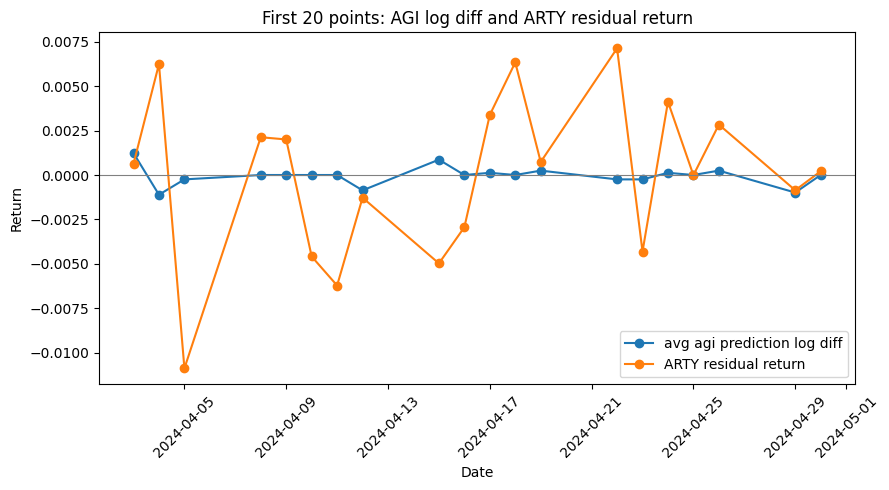

,avg agi prediction log diff,ARTY residual return
Date,,
2024-04-03,0.001232,0.000624
2024-04-04,-0.001109,0.006239
2024-04-05,-0.000247,-0.010873
2024-04-08,0.000000,0.002124
2024-04-09,0.000000,0.002000
2024-04-10,0.000000,-0.004582
2024-04-11,0.000000,-0.006215
2024-04-12,-0.000863,-0.001275
2024-04-15,0.000863,-0.004971


In [29]:
import matplotlib.pyplot as plt

plot_df = (
    df_analysis[["avg agi prediction log diff", "ARTY residual return"]]
    .dropna()
    .head(20)
    .copy()
)

plt.figure(figsize=(9, 5))
plt.plot(
    plot_df.index,
    plot_df["avg agi prediction log diff"],
    marker="o",
    linewidth=1.5,
    label="avg agi prediction log diff",
)
plt.plot(
    plot_df.index,
    plot_df["ARTY residual return"],
    marker="o",
    linewidth=1.5,
    label="ARTY residual return",
)
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("First 20 points: AGI log diff and ARTY residual return")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(plot_df)

## EDA diagnostics suite
This section adds distributional diagnostics, dependence diagnostics, prewhitening-based cross-correlation checks, stationarity tests, structural-break diagnostics, and ARCH/volatility checks for:
- $y_t$: ARTY residual return
- $x_t$: average AGI prediction log difference

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import skew, kurtosis, jarque_bera
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, breaks_cusumolsresid, recursive_olsresiduals
from statsmodels.tsa.stattools import adfuller, ccf, kpss, zivot_andrews
from arch.unitroot import PhillipsPerron
import ruptures as rpt

eda_df = (
    df_analysis[["avg agi prediction log diff", "ARTY residual return", "time_idx"]]
    .dropna()
    .rename(columns={
        "avg agi prediction log diff": "x_t",
        "ARTY residual return": "y_t",
    })
    .copy()
)

eda_df["y2_t"] = eda_df["y_t"] ** 2
eda_df["x2_t"] = eda_df["x_t"] ** 2
eda_df["abs_y_t"] = eda_df["y_t"].abs()
eda_df["yx_t"] = eda_df["y_t"] * eda_df["x_t"]

print(f"EDA sample size: {len(eda_df)}")
display(eda_df.head())

EDA sample size: 439


,x_t,y_t,time_idx,y2_t,x2_t,abs_y_t,yx_t
Date,,,,,,,
2024-04-03,0.001232,0.000624,1.0,3.896690e-07,1.517781e-06,0.000624,7.690462e-07
2024-04-04,-0.001109,0.006239,2.0,3.892105e-05,1.229251e-06,0.006239,-6.916916e-06
2024-04-05,-0.000247,-0.010873,3.0,1.182240e-04,6.078608e-08,0.010873,2.680742e-06
2024-04-08,0.000000,0.002124,4.0,4.513342e-06,0.000000e+00,0.002124,0.000000e+00
2024-04-09,0.000000,0.002000,5.0,3.998960e-06,0.000000e+00,0.002000,0.000000e+00


## Part C: Exploratory Data Analysis & Feature Engineering

Construct the joint time series (x_t = AGI year shift, y_t = ARTY idiosyncratic return) with time-indexed lags for lagged regression analysis. Verify stationarity and cross-correlation structure.

Summary/distribution diagnostics (JB reported descriptively):


,series,n,mean,median,std,skew,kurtosis,q01,q05,q95,q99,jarque_bera_stat,jarque_bera_pvalue
0,ARTY (residual return),439,0.000004,0.000148,0.008075,-0.771701,6.195291,-0.019759,-0.011921,0.012544,0.020283,726.435894,1.804887e-158
1,AGI (log diff),439,0.000002,0.000000,0.000262,-0.120417,9.634027,-0.000987,-0.000247,0.000247,0.000987,1655.706278,0.000000e+00


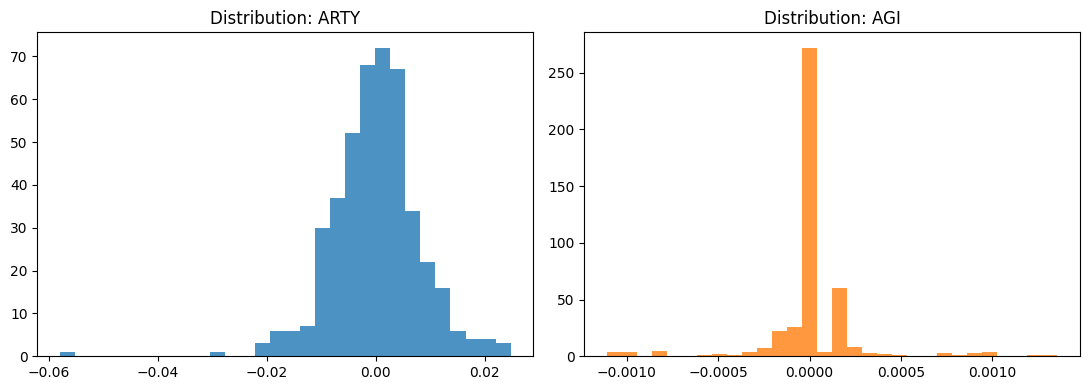

In [31]:
# 1) Summary statistics + distributional diagnostics
def summarize_series(series: pd.Series, name: str) -> pd.DataFrame:
    clean = series.dropna()
    q = clean.quantile([0.01, 0.05, 0.95, 0.99])
    jb_stat, jb_p = jarque_bera(clean)
    out = pd.DataFrame({
        "series": [name],
        "n": [len(clean)],
        "mean": [clean.mean()],
        "median": [clean.median()],
        "std": [clean.std(ddof=1)],
        "skew": [skew(clean, bias=False)],
        "kurtosis": [kurtosis(clean, fisher=True, bias=False)],
        "q01": [q.loc[0.01]],
        "q05": [q.loc[0.05]],
        "q95": [q.loc[0.95]],
        "q99": [q.loc[0.99]],
        "jarque_bera_stat": [jb_stat],
        "jarque_bera_pvalue": [jb_p],
    })
    return out

summary_table = pd.concat(
    [
        summarize_series(eda_df["y_t"], "ARTY (residual return)"),
        summarize_series(eda_df["x_t"], "AGI (log diff)"),
    ],
    ignore_index=True,
)

print("Summary/distribution diagnostics (JB reported descriptively):")
display(summary_table)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(eda_df["y_t"], bins=30, alpha=0.8)
axes[0].set_title("Distribution: ARTY")
axes[1].hist(eda_df["x_t"], bins=30, alpha=0.8, color="C1")
axes[1].set_title("Distribution: AGI")
plt.tight_layout()
plt.show()

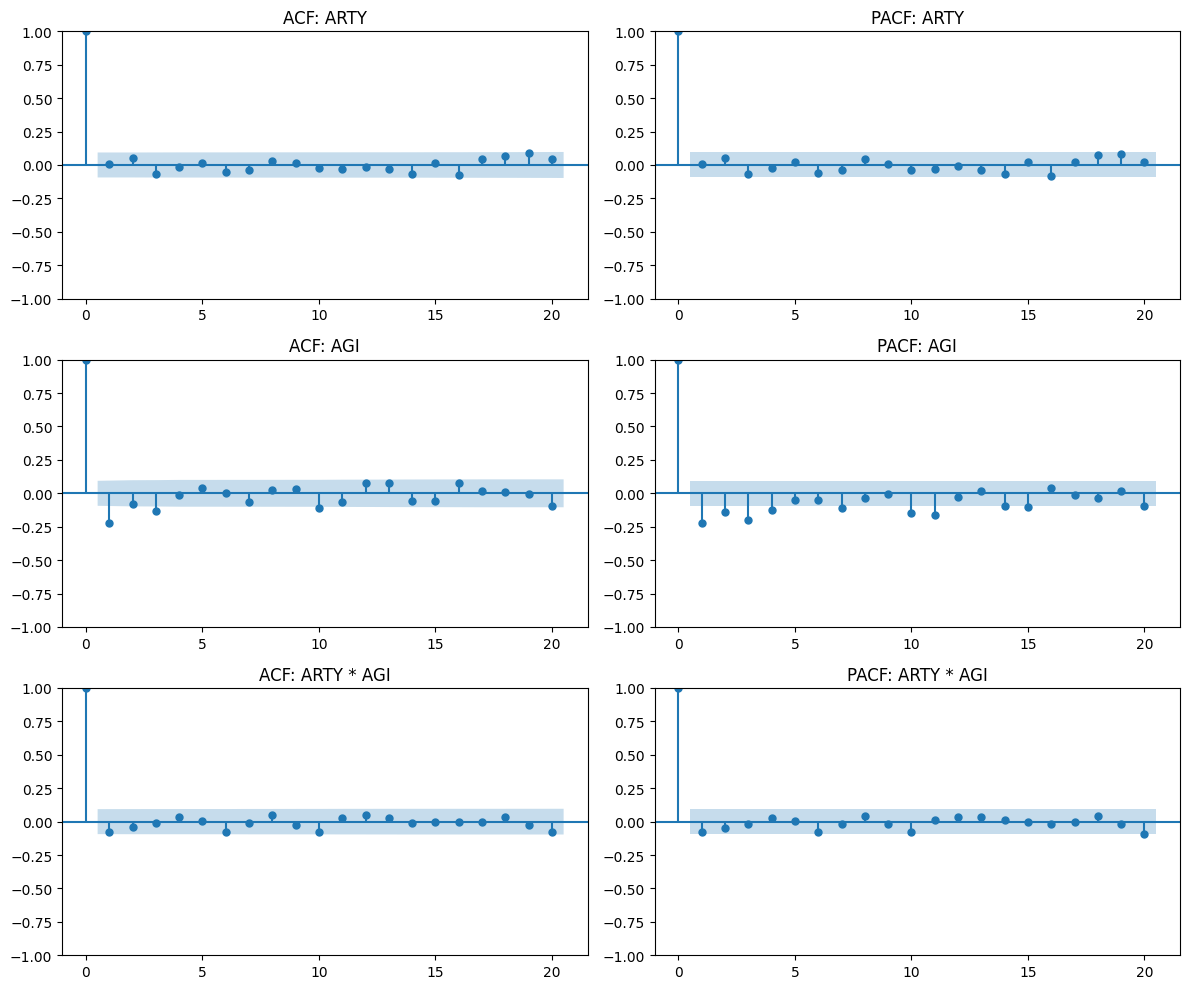

/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood opti

Ljung-Box on AR(1) residuals for ARTY:


,lb_stat,lb_pvalue
5,3.570384,0.612765
10,6.249080,0.793920
20,19.588453,0.483924


Ljung-Box on AR(1) residuals for AGI:


,lb_stat,lb_pvalue
5,28.649935,0.000027
10,38.206155,0.000035
20,59.420495,0.000009


In [32]:
# 2) ACF/PACF + portmanteau diagnostics
max_lag = min(20, len(eda_df) // 5)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
plot_acf(eda_df["y_t"], lags=max_lag, ax=axes[0, 0])
axes[0, 0].set_title("ACF: ARTY")
plot_pacf(eda_df["y_t"], lags=max_lag, method="ywm", ax=axes[0, 1])
axes[0, 1].set_title("PACF: ARTY")

plot_acf(eda_df["x_t"], lags=max_lag, ax=axes[1, 0])
axes[1, 0].set_title("ACF: AGI")
plot_pacf(eda_df["x_t"], lags=max_lag, method="ywm", ax=axes[1, 1])
axes[1, 1].set_title("PACF: AGI")

plot_acf(eda_df["yx_t"], lags=max_lag, ax=axes[2, 0])
axes[2, 0].set_title("ACF: ARTY * AGI")
plot_pacf(eda_df["yx_t"], lags=max_lag, method="ywm", ax=axes[2, 1])
axes[2, 1].set_title("PACF: ARTY * AGI")

plt.tight_layout()
plt.show()

# Preliminary mean models for residual diagnostics
y_mod = sm.tsa.ARIMA(eda_df["y_t"], order=(1, 0, 0)).fit()
x_mod = sm.tsa.ARIMA(eda_df["x_t"], order=(1, 0, 0)).fit()

lb_y = acorr_ljungbox(y_mod.resid.dropna(), lags=[5, 10, 20], return_df=True)
lb_x = acorr_ljungbox(x_mod.resid.dropna(), lags=[5, 10, 20], return_df=True)

print("Ljung-Box on AR(1) residuals for ARTY:")
display(lb_y)
print("Ljung-Box on AR(1) residuals for AGI:")
display(lb_x)

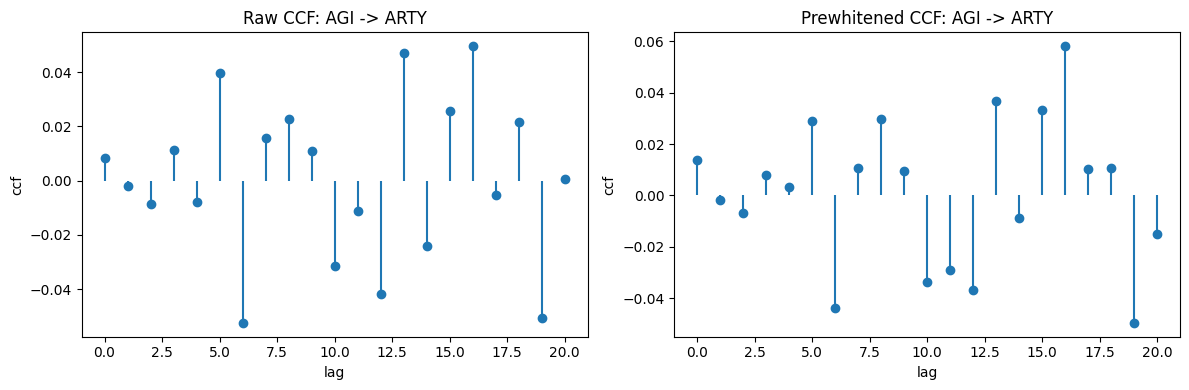

Top raw CCF lags by |corr|:


,lag,ccf,abs_ccf
6,6,-0.052357,0.052357
19,19,-0.050630,0.050630
16,16,0.049521,0.049521
13,13,0.047072,0.047072
12,12,-0.041880,0.041880
5,5,0.039721,0.039721
10,10,-0.031457,0.031457
15,15,0.025520,0.025520


Top prewhitened CCF lags by |corr|:


,lag,ccf,abs_ccf
16,16,0.058165,0.058165
19,19,-0.049622,0.049622
6,6,-0.043644,0.043644
13,13,0.036765,0.036765
12,12,-0.036690,0.036690
10,10,-0.033802,0.033802
15,15,0.033400,0.033400
8,8,0.029925,0.029925


In [33]:
# 3) Cross-correlation and prewhitening diagnostics
def ccf_df(a: pd.Series, b: pd.Series, max_lag: int = 20) -> pd.DataFrame:
    a = a.dropna()
    b = b.dropna()
    idx = a.index.intersection(b.index)
    a = a.loc[idx]
    b = b.loc[idx]
    vals = ccf(a, b, adjusted=False)[: max_lag + 1]
    out = pd.DataFrame({"lag": np.arange(len(vals)), "ccf": vals})
    return out

raw_ccf = ccf_df(eda_df["x_t"], eda_df["y_t"], max_lag=max_lag)

# Prewhiten AGI with AR(1), then apply same AR filter to ARTY
phi = x_mod.arparams[0] if len(x_mod.arparams) > 0 else 0.0
x_pw = eda_df["x_t"] - phi * eda_df["x_t"].shift(1)
y_filt = eda_df["y_t"] - phi * eda_df["y_t"].shift(1)
pw_df = pd.concat([x_pw.rename("x_pw"), y_filt.rename("y_filt")], axis=1).dropna()
pw_ccf = ccf_df(pw_df["x_pw"], pw_df["y_filt"], max_lag=max_lag)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].stem(raw_ccf["lag"], raw_ccf["ccf"], basefmt=" ")
axes[0].set_title("Raw CCF: AGI -> ARTY")
axes[0].set_xlabel("lag")
axes[0].set_ylabel("ccf")

axes[1].stem(pw_ccf["lag"], pw_ccf["ccf"], basefmt=" ")
axes[1].set_title("Prewhitened CCF: AGI -> ARTY")
axes[1].set_xlabel("lag")
axes[1].set_ylabel("ccf")

plt.tight_layout()
plt.show()

print("Top raw CCF lags by |corr|:")
display(raw_ccf.assign(abs_ccf=raw_ccf["ccf"].abs()).sort_values("abs_ccf", ascending=False).head(8))
print("Top prewhitened CCF lags by |corr|:")
display(pw_ccf.assign(abs_ccf=pw_ccf["ccf"].abs()).sort_values("abs_ccf", ascending=False).head(8))

In [34]:
# 4) Stationarity and unit-root battery
def stationarity_battery(series: pd.Series, name: str) -> pd.DataFrame:
    s = series.dropna()
    adf_res = adfuller(s, autolag="AIC")
    pp_res = PhillipsPerron(s)
    kpss_res = kpss(s, nlags="auto")
    za_res = zivot_andrews(s, maxlag=10, regression="c", autolag="AIC")

    return pd.DataFrame({
        "series": [name],
        "ADF stat": [adf_res[0]],
        "ADF p": [adf_res[1]],
        "PP stat": [pp_res.stat],
        "PP p": [pp_res.pvalue],
        "KPSS stat": [kpss_res[0]],
        "KPSS p": [kpss_res[1]],
        "ZA stat": [za_res[0]],
        "ZA p": [za_res[1]],
        "ZA break index": [za_res[3]],
    })

stationarity_table = pd.concat(
    [
        stationarity_battery(eda_df["y_t"], "ARTY"),
        stationarity_battery(eda_df["x_t"], "AGI"),
    ],
    ignore_index=True,
)

print("Stationarity battery (KPSS null = stationarity):")
display(stationarity_table)

Stationarity battery (KPSS null = stationarity):


/var/folders/h9/cypcrhp14dn4gqqq118p8dyh0000gn/T/ipykernel_85670/506916217.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(s, nlags="auto")
/var/folders/h9/cypcrhp14dn4gqqq118p8dyh0000gn/T/ipykernel_85670/506916217.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(s, nlags="auto")


,series,ADF stat,ADF p,PP stat,PP p,KPSS stat,KPSS p,ZA stat,ZA p,ZA break index
0,ARTY,-20.781781,0.000000e+00,-20.897472,0.0,0.117788,0.1,-20.938641,0.00001,0
1,AGI,-8.728214,3.244801e-14,-37.248307,0.0,0.137934,0.1,-10.395852,0.00001,10


CUSUM test p-value: 0.6512


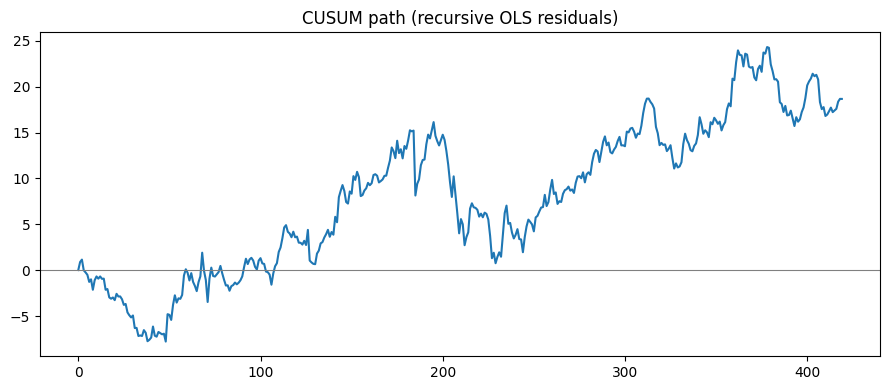

Estimated break indices (excluding end): [30, 65, 80]
Approximate break dates: [Timestamp('2024-05-14 00:00:00'), Timestamp('2024-07-05 00:00:00'), Timestamp('2024-07-26 00:00:00')]


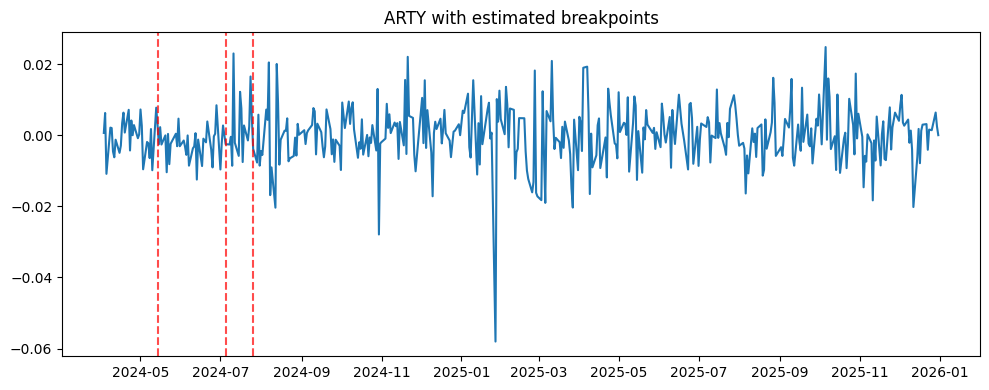

In [35]:
# 5) Structural breaks and regime shifts
ols_break_mod = sm.OLS(eda_df["y_t"], sm.add_constant(eda_df[["x_t"]])).fit()

# CUSUM (Brown-Durbin-Evans style)
cusum_stat, cusum_p, _ = breaks_cusumolsresid(ols_break_mod.resid, ddof=2)
print(f"CUSUM test p-value: {cusum_p:.4g}")

# Recursive residuals / CUSUM path
rec_out = recursive_olsresiduals(ols_break_mod, skip=20)
cusum_path = rec_out[-2]
plt.figure(figsize=(9, 4))
plt.plot(cusum_path)
plt.title("CUSUM path (recursive OLS residuals)")
plt.axhline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

# Multiple change-point detection on ARTY mean (Bai-Perron-style objective proxy)
signal = eda_df["y_t"].to_numpy()
algo = rpt.Binseg(model="l2").fit(signal)
bkps = algo.predict(n_bkps=3)
break_locs = [int(i) for i in bkps[:-1]]

print("Estimated break indices (excluding end):", break_locs)
if break_locs:
    break_dates = [eda_df.index[i - 1] for i in break_locs if i - 1 < len(eda_df)]
    print("Approximate break dates:", break_dates)

plt.figure(figsize=(10, 4))
plt.plot(eda_df.index, eda_df["y_t"], label="ARTY")
for i in break_locs:
    if i - 1 < len(eda_df):
        plt.axvline(eda_df.index[i - 1], color="red", linestyle="--", alpha=0.7)
plt.title("ARTY with estimated breakpoints")
plt.tight_layout()
plt.show()

Engle ARCH diagnostic (ARTY):


,metric,value
0,LM stat,4.497671
1,LM p-value,0.922117
2,F stat,0.442878
3,F p-value,0.924910


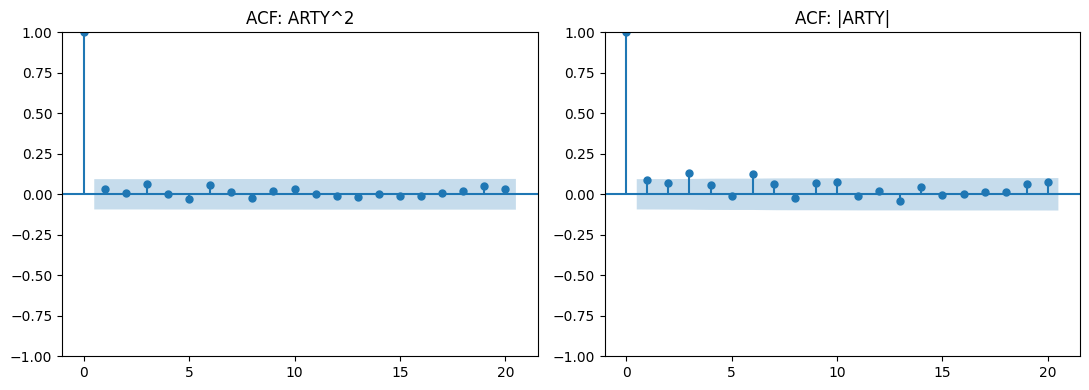

In [36]:
# 6) Volatility clustering / ARCH diagnostics
arch_lm = het_arch(eda_df["y_t"].dropna(), nlags=10)
arch_labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
arch_table = pd.DataFrame({"metric": arch_labels, "value": arch_lm})

print("Engle ARCH diagnostic (ARTY):")
display(arch_table)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_acf(eda_df["y2_t"].dropna(), lags=max_lag, ax=axes[0])
axes[0].set_title("ACF: ARTY^2")
plot_acf(eda_df["abs_y_t"].dropna(), lags=max_lag, ax=axes[1])
axes[1].set_title("ACF: |ARTY|")
plt.tight_layout()
plt.show()

## Model selection toolkit for dynamic sensitivity
We keep stationary variables and compare baseline mean dynamics (`ARDL`), system dynamics (`VAR`), and robust impulse responses (`Local Projections`).

In [37]:
# Setup for model selection
model_df = eda_df[["y_t", "x_t", "time_idx"]].dropna().copy()
max_p = 10  # daily data: allow broader lag search
max_q = 10
max_var_lag = 10
irf_h = 10

print(f"Model sample size: {len(model_df)}")
display(model_df.head())

Model sample size: 439


,y_t,x_t,time_idx
Date,,,
2024-04-03,0.000624,0.001232,1.0
2024-04-04,0.006239,-0.001109,2.0
2024-04-05,-0.010873,-0.000247,3.0
2024-04-08,0.002124,0.000000,4.0
2024-04-09,0.002000,0.000000,5.0


In [38]:
# 1) ARDL-style dynamic regression lag search (AIC/BIC)
def build_ardl_matrix(df: pd.DataFrame, p: int, q: int) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    out["y"] = df["y_t"]
    for i in range(1, p + 1):
        out[f"y_lag{i}"] = df["y_t"].shift(i)
    for j in range(0, q + 1):
        out[f"x_lag{j}"] = df["x_t"].shift(j)
    return out.dropna()

ardl_results = []
for p in range(1, max_p + 1):
    for q in range(0, max_q + 1):
        tmp = build_ardl_matrix(model_df, p, q)
        if len(tmp) < 60:
            continue
        y_tmp = tmp["y"]
        X_tmp = sm.add_constant(tmp.drop(columns=["y"]))
        fit_tmp = sm.OLS(y_tmp, X_tmp).fit()
        lb_p = acorr_ljungbox(fit_tmp.resid, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
        ardl_results.append({
            "p": p,
            "q": q,
            "n": len(tmp),
            "aic": fit_tmp.aic,
            "bic": fit_tmp.bic,
            "adj_r2": fit_tmp.rsquared_adj,
            "lb_pvalue_lag10": lb_p,
        })

ardl_grid = pd.DataFrame(ardl_results).sort_values(["bic", "aic"]).reset_index(drop=True)
best_p = int(ardl_grid.loc[0, "p"]); best_q = int(ardl_grid.loc[0, "q"])
best_data = build_ardl_matrix(model_df, best_p, best_q)
best_y = best_data["y"]
best_X = sm.add_constant(best_data.drop(columns=["y"]))
ardl_ols = sm.OLS(best_y, best_X).fit()
ardl_hac = sm.OLS(best_y, best_X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

dist_lag_sum = sum(ardl_hac.params.get(f"x_lag{j}", 0.0) for j in range(best_q + 1))

print("Top ARDL candidates by BIC:")
display(ardl_grid.head(10))
print(f"Selected ARDL(p={best_p}, q={best_q})")
print(f"Distributed-lag sum Σβ_j: {dist_lag_sum:.6f}")
display(ardl_hac.summary2().tables[1].head(15))

Top ARDL candidates by BIC:


,p,q,n,aic,bic,adj_r2,lb_pvalue_lag10
0,1,0,438,-2972.493505,-2960.246848,-0.004512,0.796338
1,1,1,438,-2970.858265,-2954.529389,-0.005989,0.802043
2,2,0,437,-2964.687874,-2948.368141,-0.003630,0.860540
3,2,1,437,-2962.903174,-2942.503508,-0.005458,0.865504
4,1,2,437,-2961.589214,-2941.189548,-0.008486,0.800603
5,3,0,436,-2958.673908,-2938.285697,-0.001426,0.937647
6,2,2,437,-2960.909195,-2936.429596,-0.007777,0.864948
7,3,1,436,-2956.699332,-2932.233478,-0.003696,0.939326
8,1,3,436,-2953.441562,-2928.975709,-0.011224,0.766123
9,3,2,436,-2954.719185,-2926.175689,-0.005990,0.939765


Selected ARDL(p=1, q=0)
Distributed-lag sum Σβ_j: 0.249796


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
const,0.000002,0.000386,0.005964,0.995242,-0.000754,0.000759
y_lag1,0.004767,0.042575,0.111972,0.910846,-0.078679,0.088213
x_lag0,0.249796,0.939921,0.265762,0.790422,-1.592416,2.092007


VAR lag-order selection:


/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,criterion,selected_lag
0,aic,3
1,bic,0
2,hqic,3
3,fpe,3


Fitted VAR lag: 3
VAR stability (roots outside unit circle): True
Portmanteau whiteness p-value (nlags=10): 0.3642


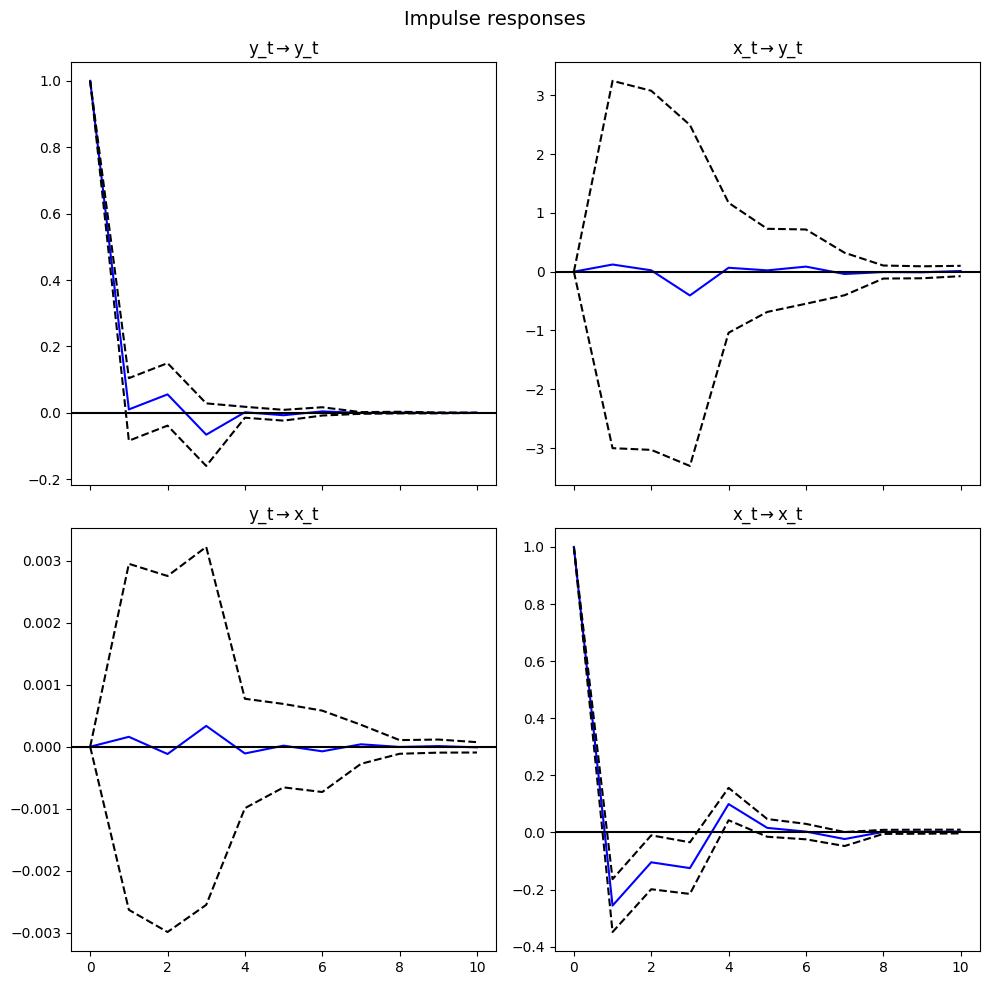

In [39]:
# 2) VAR lag selection + reduced-form IRFs
var_model = sm.tsa.VAR(model_df[["y_t", "x_t"]])
lag_sel = var_model.select_order(maxlags=max_var_lag)
var_lag_choice = lag_sel.selected_orders.get("bic")
if var_lag_choice is None or var_lag_choice < 1:
    var_lag_choice = lag_sel.selected_orders.get("aic")
if var_lag_choice is None or var_lag_choice < 1:
    var_lag_choice = 1

var_fit = var_model.fit(var_lag_choice)
var_is_stable = var_fit.is_stable()
var_white = var_fit.test_whiteness(nlags=10)

print("VAR lag-order selection:")
display(pd.DataFrame({
    "criterion": ["aic", "bic", "hqic", "fpe"],
    "selected_lag": [
        lag_sel.selected_orders.get("aic"),
        lag_sel.selected_orders.get("bic"),
        lag_sel.selected_orders.get("hqic"),
        lag_sel.selected_orders.get("fpe"),
    ],
}))

print(f"Fitted VAR lag: {var_lag_choice}")
print(f"VAR stability (roots outside unit circle): {var_is_stable}")
print(f"Portmanteau whiteness p-value (nlags=10): {var_white.pvalue:.4g}")

irf_obj = var_fit.irf(irf_h)
irf_obj.plot(orth=False)
plt.tight_layout()
plt.show()

,h,theta,se,lo95,hi95,n
0,0,0.651988,1.046374,-1.398904,2.702881,437
1,1,0.128553,0.999466,-1.830401,2.087507,436
2,2,0.179889,1.480126,-2.721158,3.080937,435
3,3,-0.459386,1.060121,-2.537224,1.618451,434
4,4,-0.253509,0.999533,-2.212593,1.705576,433
5,5,-0.741704,1.205226,-3.103947,1.620538,432
6,6,-1.606657,1.067268,-3.698502,0.485188,431
7,7,0.415678,1.287594,-2.108006,2.939363,430
8,8,-1.010440,1.390766,-3.736342,1.715462,429
9,9,2.352486,1.046987,0.300391,4.404581,428


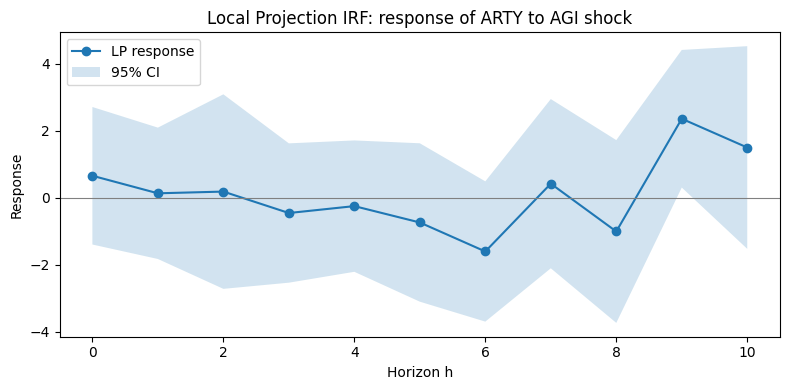

In [40]:
# 3) Local Projections (LP) IRF: y_{t+h} on x_t
lp_horizons = list(range(irf_h + 1))
lp_lags = 2
lp_rows = []

for h in lp_horizons:
    tmp = pd.DataFrame(index=model_df.index)
    tmp["y_lead"] = model_df["y_t"].shift(-h)
    tmp["x0"] = model_df["x_t"]
    for lag in range(1, lp_lags + 1):
        tmp[f"y_lag{lag}"] = model_df["y_t"].shift(lag)
        tmp[f"x_lag{lag}"] = model_df["x_t"].shift(lag)
    tmp = tmp.dropna()

    y_lp = tmp["y_lead"]
    X_lp = sm.add_constant(tmp.drop(columns=["y_lead"]))
    fit_lp = sm.OLS(y_lp, X_lp).fit(cov_type="HAC", cov_kwds={"maxlags": max(1, h + 1)})

    coef = fit_lp.params["x0"]
    se = fit_lp.bse["x0"]
    lp_rows.append({
        "h": h,
        "theta": coef,
        "se": se,
        "lo95": coef - 1.96 * se,
        "hi95": coef + 1.96 * se,
        "n": len(tmp),
    })

lp_irf = pd.DataFrame(lp_rows)
display(lp_irf)

plt.figure(figsize=(8, 4))
plt.plot(lp_irf["h"], lp_irf["theta"], marker="o", label="LP response")
plt.fill_between(lp_irf["h"], lp_irf["lo95"], lp_irf["hi95"], alpha=0.2, label="95% CI")
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Local Projection IRF: response of ARTY to AGI shock")
plt.xlabel("Horizon h")
plt.ylabel("Response")
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
# 4) Compact model comparison summary
model_compare = pd.DataFrame([
    {
        "model": "ARDL (baseline)",
        "selected_order": f"p={best_p}, q={best_q}",
        "fit_metric": float(ardl_ols.bic),
        "fit_metric_name": "BIC",
        "diagnostic": float(acorr_ljungbox(ardl_ols.resid, lags=[10], return_df=True)["lb_pvalue"].iloc[0]),
        "diagnostic_name": "Ljung-Box p(10)",
        "key_effect": float(dist_lag_sum),
        "key_effect_name": "Σ beta_x_lags",
    },
    {
        "model": "VAR (system)",
        "selected_order": f"p={var_lag_choice}",
        "fit_metric": float(var_fit.aic),
        "fit_metric_name": "AIC",
        "diagnostic": float(var_white.pvalue),
        "diagnostic_name": "Whiteness p(10)",
        "key_effect": float(irf_obj.irfs[1, 0, 1]),
        "key_effect_name": "IRF h=1 (AGI->ARTY)",
    },
    {
        "model": "Local Projections",
        "selected_order": f"lags={lp_lags}",
        "fit_metric": float(lp_irf.loc[0, "se"]),
        "fit_metric_name": "SE(h=0)",
        "diagnostic": float(lp_irf["n"].min()),
        "diagnostic_name": "Min sample across h",
        "key_effect": float(lp_irf.loc[0, "theta"]),
        "key_effect_name": "Impact theta(h=0)",
    },
])

print("Model comparison snapshot:")
display(model_compare)

print("Next identification decision for structural interpretation:")
print("If you want SVAR next, choose identification: Cholesky ordering, sign restrictions, or external instrument (SVAR-IV).")

Model comparison snapshot:


,model,selected_order,fit_metric,fit_metric_name,diagnostic,diagnostic_name,key_effect,key_effect_name
0,ARDL (baseline),"p=1, q=0",-2960.246848,BIC,0.796338,Ljung-Box p(10),0.249796,Σ beta_x_lags
1,VAR (system),p=3,-26.268182,AIC,0.364202,Whiteness p(10),0.121881,IRF h=1 (AGI->ARTY)
2,Local Projections,lags=2,1.046374,SE(h=0),427.000000,Min sample across h,0.651988,Impact theta(h=0)


Next identification decision for structural interpretation:
If you want SVAR next, choose identification: Cholesky ordering, sign restrictions, or external instrument (SVAR-IV).


## Predictive Benchmark
This section compares traditional time-series candidates (VAR, SVAR, and VECM), runs a Johansen cointegration test, and selects the downstream simulation model using information criteria (BIC primary, AIC tie-break).

In [42]:
# ====================================================
# Predictive benchmark on AGI case: VAR, SVAR, and VECM
# Target relationship: x_t -> y_t
# Benchmark criterion: BIC (primary), AIC (tie-break)
# ====================================================

import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen

if "model_df" not in globals() or not isinstance(model_df, pd.DataFrame):
    raise ValueError("model_df is required. Run the model setup cell first.")

required_cols = ["x_t", "y_t"]
missing = [c for c in required_cols if c not in model_df.columns]
if missing:
    raise ValueError(f"Missing required columns in model_df: {missing}")

ts_df = model_df[required_cols].dropna().copy().reset_index(drop=True)
if len(ts_df) < 40:
    raise ValueError(f"Not enough observations for robust model comparison: {len(ts_df)}")

print(f"Total observations used for VAR/SVAR/VECM comparison: {len(ts_df)}")
display(ts_df.head())

max_lag = min(10, max(2, len(ts_df) // 8))

# -----------------------------
# VAR candidates
# -----------------------------
var_candidates = []
for p in range(1, max_lag + 1):
    try:
        fit = VAR(ts_df).fit(p)
        var_candidates.append({
            "Model": "VAR",
            "lag": int(p),
            "k_ar_diff": np.nan,
            "coint_rank": np.nan,
            "AIC": float(fit.aic),
            "BIC": float(fit.bic),
            "HQIC": float(fit.hqic),
            "fit": fit,
        })
    except Exception as exc:
        print(f"VAR lag {p} failed: {exc}")

if not var_candidates:
    raise RuntimeError("All VAR candidates failed.")

# -----------------------------
# SVAR candidates (A-model: x_t contemporaneously affects y_t)
# -----------------------------
svar_candidates = []
A_template = np.array([[1, 0], ["E", 1]], dtype=object)

for p in range(1, max_lag + 1):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            mod = SVAR(ts_df, svar_type="A", A=A_template)
            fit = mod.fit(maxlags=p, ic=None, trend="c", solver="nm", maxiter=2000, maxfun=4000)

        p_eff = int(fit.k_ar)
        if p_eff < 1:
            continue

        svar_candidates.append({
            "Model": "SVAR",
            "lag": p_eff,
            "k_ar_diff": np.nan,
            "coint_rank": np.nan,
            "AIC": float(fit.aic),
            "BIC": float(fit.bic),
            "HQIC": float(fit.hqic),
            "fit": fit,
        })
    except Exception as exc:
        print(f"SVAR lag {p} failed: {exc}")

if not svar_candidates:
    print("SVAR candidates failed; proceeding with VAR/VECM results.")

# -----------------------------
# Cointegration test and VECM candidates
# -----------------------------
vecm_candidates = []
cointegration_info_agi = {"tested": False, "rank_trace_5pct": 0, "trace_table": None}

try:
    det_order = 0
    k_ar_diff_j = min(5, max(1, len(ts_df) // 20))
    johansen_res = coint_johansen(ts_df, det_order=det_order, k_ar_diff=k_ar_diff_j)

    trace_stats = johansen_res.lr1
    crit_5pct = johansen_res.cvt[:, 1]
    rank_trace_5pct = int(np.sum(trace_stats > crit_5pct))
    n_vars = ts_df.shape[1]

    trace_table = pd.DataFrame({
        "r <= i": [f"r <= {i}" for i in range(n_vars)],
        "trace_stat": trace_stats,
        "critical_5pct": crit_5pct,
        "reject_at_5pct": trace_stats > crit_5pct,
    })
    cointegration_info_agi = {
        "tested": True,
        "rank_trace_5pct": rank_trace_5pct,
        "k_ar_diff_johansen": k_ar_diff_j,
        "trace_table": trace_table,
    }

    print("Johansen trace test (5% level):")
    display(trace_table)
    print(f"Inferred cointegration rank (trace, 5%): {rank_trace_5pct}")

    if 1 <= rank_trace_5pct < n_vars:
        vecm_rank = int(rank_trace_5pct)
        max_k_ar_diff = min(8, max(1, len(ts_df) // 10))
        for k_ar_diff in range(1, max_k_ar_diff + 1):
            try:
                fit = VECM(ts_df, coint_rank=vecm_rank, k_ar_diff=k_ar_diff, deterministic="co").fit()
                vecm_candidates.append({
                    "Model": "VECM",
                    "lag": int(k_ar_diff + 1),
                    "k_ar_diff": int(k_ar_diff),
                    "coint_rank": int(vecm_rank),
                    "AIC": float(getattr(fit, "aic", np.nan)),
                    "BIC": float(getattr(fit, "bic", np.nan)),
                    "HQIC": float(getattr(fit, "hqic", np.nan)),
                    "fit": fit,
                })
            except Exception as exc:
                print(f"VECM k_ar_diff {k_ar_diff} failed: {exc}")

        if not vecm_candidates:
            print("VECM considered but all candidates failed.")
    else:
        print("VECM not included: inferred rank is not in [1, n_vars-1].")
except Exception as exc:
    print(f"Cointegration/VECM step failed: {exc}")

# -----------------------------
# Combine and rank by BIC (primary) then AIC
# -----------------------------
all_candidates = var_candidates + svar_candidates + vecm_candidates
if not all_candidates:
    raise RuntimeError("No valid model candidates were estimated.")

model_compare_agi_pred = pd.DataFrame([{k: v for k, v in c.items() if k != "fit"} for c in all_candidates])
model_compare_agi_pred = model_compare_agi_pred.sort_values(["BIC", "AIC"], na_position="last").reset_index(drop=True)

print("Predictive model comparison (lower is better):")
display(model_compare_agi_pred)

best_var_pred = min(var_candidates, key=lambda x: x["BIC"]) if var_candidates else None
best_svar_pred = min(svar_candidates, key=lambda x: x["BIC"]) if svar_candidates else None
best_vecm_pred = None
if vecm_candidates:
    finite_vecm = [c for c in vecm_candidates if np.isfinite(c["BIC"]) and np.isfinite(c["AIC"])]
    best_vecm_pred = min(finite_vecm, key=lambda x: x["BIC"]) if finite_vecm else None

selectable = [c for c in all_candidates if np.isfinite(c["BIC"]) and np.isfinite(c["AIC"])]
if not selectable:
    raise RuntimeError("No candidates with finite AIC/BIC available for model selection.")
best_overall = min(selectable, key=lambda x: (x["BIC"], x["AIC"]))

if best_var_pred is not None:
    print(f"Best VAR by BIC: lag={best_var_pred['lag']}, BIC={best_var_pred['BIC']:.6f}, AIC={best_var_pred['AIC']:.6f}")
if best_svar_pred is not None:
    print(f"Best SVAR by BIC: lag={best_svar_pred['lag']}, BIC={best_svar_pred['BIC']:.6f}, AIC={best_svar_pred['AIC']:.6f}")
if best_vecm_pred is not None:
    print(
        f"Best VECM by BIC: k_ar_diff={best_vecm_pred['k_ar_diff']}, coint_rank={best_vecm_pred['coint_rank']}, "
        f"BIC={best_vecm_pred['BIC']:.6f}, AIC={best_vecm_pred['AIC']:.6f}"
    )
print(
    f"Selected predictive model: {best_overall['Model']} "
    f"(lag={best_overall['lag']}, k_ar_diff={best_overall['k_ar_diff']})"
)

best_models_agi_pred = {
    "VAR": best_var_pred,
    "SVAR": best_svar_pred,
    "VECM": best_vecm_pred,
    "selected_model": best_overall["Model"],
    "selected_lag": best_overall["lag"],
    "selected_k_ar_diff": best_overall["k_ar_diff"],
    "model_compare_agi_pred": model_compare_agi_pred,
    "cointegration_info": cointegration_info_agi,
    "ts_df": ts_df,
}

Total observations used for VAR/SVAR/VECM comparison: 439


,x_t,y_t
0,0.001232,0.000624
1,-0.001109,0.006239
2,-0.000247,-0.010873
3,0.000000,0.002124
4,0.000000,0.002000


Johansen trace test (5% level):


,r <= i,trace_stat,critical_5pct,reject_at_5pct
0,r <= 0,189.226033,15.4943,True
1,r <= 1,74.217246,3.8415,True


Inferred cointegration rank (trace, 5%): 2
VECM not included: inferred rank is not in [1, n_vars-1].
Predictive model comparison (lower is better):


,Model,lag,k_ar_diff,coint_rank,AIC,BIC,HQIC
0,VAR,1,NaN,NaN,-26.208535,-26.152614,-26.186470
1,SVAR,1,NaN,NaN,-26.208535,-26.152614,-26.186470
2,VAR,2,NaN,NaN,-26.236123,-26.142761,-26.199281
3,SVAR,2,NaN,NaN,-26.236123,-26.142761,-26.199281
4,VAR,3,NaN,NaN,-26.268182,-26.137249,-26.216510
5,SVAR,3,NaN,NaN,-26.268182,-26.137249,-26.216510
6,VAR,4,NaN,NaN,-26.261583,-26.092948,-26.195025
7,SVAR,4,NaN,NaN,-26.261583,-26.092948,-26.195025
8,VAR,5,NaN,NaN,-26.243847,-26.037379,-26.162350
9,SVAR,5,NaN,NaN,-26.243847,-26.037379,-26.162350


Best VAR by BIC: lag=1, BIC=-26.152614, AIC=-26.208535
Best SVAR by BIC: lag=1, BIC=-26.152614, AIC=-26.208535
Selected predictive model: VAR (lag=1, k_ar_diff=nan)


Backtest: 439 obs, min_train=146


/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.339e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 


Backtest model ranking (lower RMSE/MAE is better; higher R2 is better):


/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 6.535e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


,model,family,n_forecasts,rmse,mae,r2_backtest,directional_accuracy,pred_actual_corr
0,ElasticNet,ML,293,0.008731,0.006381,-0.006219,0.412969,-0.097766
1,Ridge,ML,293,0.008731,0.006380,-0.006224,0.409556,-0.098059
2,SVAR,Traditional,293,0.008765,0.006397,-0.014226,0.460751,-0.042236
3,GradientBoosting,ML,293,0.008777,0.006398,-0.016912,0.515358,0.009360
4,VAR,Traditional,293,0.008819,0.006412,-0.026742,0.505119,-0.081476
5,GARCH,GARCH,293,0.008963,0.006467,-0.060538,0.450512,-0.090150
6,ExtraTrees,ML,293,0.009133,0.006584,-0.101130,0.525597,-0.079216
7,RandomForest,ML,293,0.009249,0.006714,-0.129226,0.505119,-0.073544
8,SVR,ML,293,0.011080,0.008342,-0.620737,0.477816,-0.053071



*** BEST MODEL: ElasticNet ***
Family: ML | RMSE=0.008731 | MAE=0.006381 | R2=-0.006219

Family summary:


,family,n_models,best_rmse,median_rmse,best_mae,median_mae,best_directional_accuracy
0,ML,6,0.008731,0.008955,0.006380,0.006491,0.525597
1,Traditional,2,0.008765,0.008792,0.006397,0.006405,0.505119
2,GARCH,1,0.008963,0.008963,0.006467,0.006467,0.450512


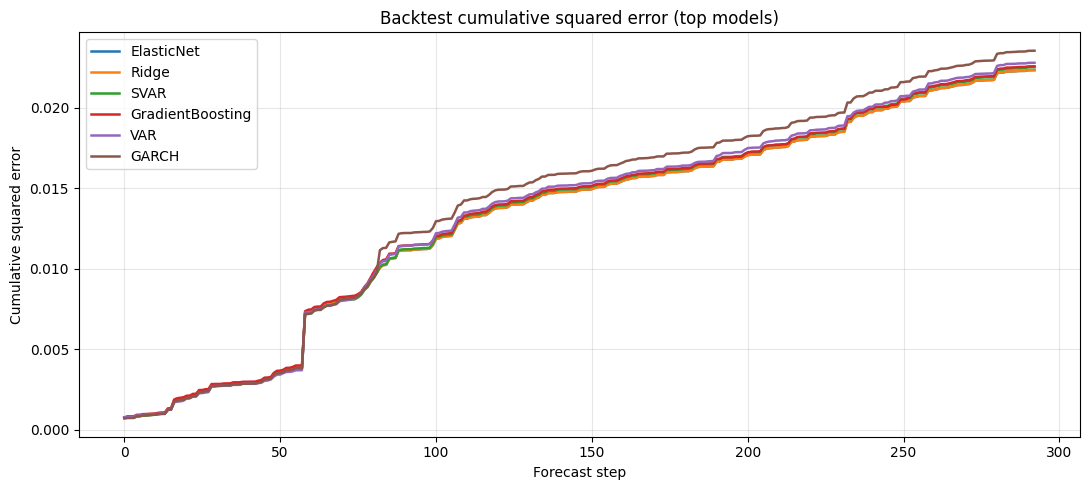

In [43]:
# ====================================================
# Expanding-window backtest: 5 models
# Traditional (1): VAR
# ML (4): ElasticNet, ExtraTrees, SVR (RBF), SVR_linear
# ====================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.base import clone

if "model_df" not in globals():
    raise ValueError("model_df is required")

bt_df = model_df[["x_t", "y_t", "time_idx"]].dropna().reset_index(drop=True) if "time_idx" in model_df.columns else model_df[["x_t", "y_t"]].dropna().reset_index(drop=True)
if len(bt_df) < 60:
    raise ValueError(f"Need >=60 observations, got {len(bt_df)}")

n_lags_ml = 3
_n_obs = len(bt_df)
min_train = max(30, _n_obs // 3)

var_lag_bt = 1
if "best_models_agi_pred" in globals():
    var_lag_bt = int(best_models_agi_pred.get("VAR", {}).get("lag", 1))

print(f"Backtest: {len(bt_df)} obs, min_train={min_train}")

def make_lagged_xy(df_slice, n_lags):
    rows = []
    for t in range(n_lags, len(df_slice)):
        rec = {"target": float(df_slice.iloc[t]["y_t"])}
        for lag in range(1, n_lags + 1):
            rec[f"x_lag{lag}"] = float(df_slice.iloc[t - lag]["x_t"])
            rec[f"y_lag{lag}"] = float(df_slice.iloc[t - lag]["y_t"])
        rows.append(rec)
    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(), pd.Series(dtype=float), []
    feature_cols = [c for c in out.columns if c != "target"]
    return out[feature_cols], out["target"], feature_cols

def make_next_features(df_slice, n_lags, feature_cols):
    rec = {}
    for lag in range(1, n_lags + 1):
        rec[f"x_lag{lag}"] = float(df_slice.iloc[-lag]["x_t"])
        rec[f"y_lag{lag}"] = float(df_slice.iloc[-lag]["y_t"])
    return pd.DataFrame([rec], columns=feature_cols)

def one_step_var(train_slice):
    try:
        _endog = train_slice[["x_t", "y_t"]]
        if "time_idx" in train_slice.columns:
            _exog = train_slice[["time_idx"]].to_numpy(dtype=float)
            fit = VAR(_endog, exog=_exog).fit(var_lag_bt)
            hist = _endog.to_numpy(dtype=float)[-fit.k_ar:]
            _exog_next = np.array([[float(train_slice["time_idx"].iloc[-1] + 1)]])
            return float(fit.forecast(hist, steps=1, exog_future=_exog_next)[0, 1])
        else:
            fit = VAR(_endog).fit(var_lag_bt)
            hist = _endog.to_numpy(dtype=float)[-fit.k_ar:]
            return float(fit.forecast(hist, steps=1)[0, 1])
    except:
        return np.nan





ml_model_space = {
    "ElasticNet": Pipeline([("scale", StandardScaler()), ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, random_state=42))]),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=400, min_samples_leaf=3, random_state=42),
    "SVR_linear": Pipeline([("scale", StandardScaler()), ("svr", SVR(C=5.0, epsilon=0.01, kernel="linear"))]),
}

def _rmse_np(y_true_arr, y_pred_arr):
    return float(np.sqrt(np.mean((y_true_arr - y_pred_arr) ** 2)))

def fit_predict_with_early_stopping(model_name, estimator, X_train, y_train, X_next):
    n = len(X_train)
    split = int(n * 0.8)
    if n < 35 or split < 20 or (n - split) < 8:
        estimator.fit(X_train, y_train)
        return float(estimator.predict(X_next)[0])
    X_tr, y_tr = X_train.iloc[:split], y_train.iloc[:split]
    X_va, y_va = X_train.iloc[split:], y_train.iloc[split:]
    if model_name == "ExtraTrees":
        best_rmse, best_n, worse_streak = np.inf, 50, 0
        for n_est in [50, 100, 200, 400]:
            est_try = clone(estimator).set_params(n_estimators=n_est)
            est_try.fit(X_tr, y_tr)
            score = _rmse_np(y_va.to_numpy(dtype=float), est_try.predict(X_va))
            if score < best_rmse + 1e-9:
                best_rmse, best_n, worse_streak = score, n_est, 0
            else:
                worse_streak += 1
                if worse_streak >= 1:
                    break
        final_est = clone(estimator).set_params(n_estimators=best_n)
        final_est.fit(X_train, y_train)
        return float(final_est.predict(X_next)[0])
    estimator.fit(X_train, y_train)
    return float(estimator.predict(X_next)[0])

# Run expanding-window backtest
rows = []
for t in range(min_train, len(bt_df)):
    train_slice = bt_df.iloc[:t].copy()
    y_true = float(bt_df.iloc[t]["y_t"])
    row = {"t": int(t), "y_true": y_true, "VAR": one_step_var(train_slice)}

    X_train, y_train, feat_cols = make_lagged_xy(train_slice, n_lags_ml)
    if len(X_train) < 25:
        for ml_name in ml_model_space.keys():
            row[ml_name] = np.nan

    else:
        X_next = make_next_features(train_slice, n_lags_ml, feat_cols)
        for ml_name, estimator in ml_model_space.items():
            try:
                row[ml_name] = fit_predict_with_early_stopping(ml_name, clone(estimator), X_train, y_train, X_next)
            except:
                row[ml_name] = np.nan

    rows.append(row)

backtest_predictions_agi = pd.DataFrame(rows)
model_cols = [c for c in backtest_predictions_agi.columns if c not in ["t", "y_true"]]

# Compute metrics
metric_rows = []
for m in model_cols:
    tmp = backtest_predictions_agi[["y_true", m]].dropna()
    if len(tmp) < 2:
        continue
    y_true_arr = tmp["y_true"].to_numpy(dtype=float)
    y_pred_arr = tmp[m].to_numpy(dtype=float)
    err = y_pred_arr - y_true_arr
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true_arr - y_true_arr.mean()) ** 2))
    r2_backtest = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    dir_acc = float(np.mean(np.sign(y_pred_arr) == np.sign(y_true_arr)))
    corr = float(tmp[m].corr(tmp["y_true"])) if len(tmp) > 2 else np.nan
    family = "Traditional" if m == "VAR" else "ML"
    metric_rows.append({"model": m, "family": family, "n_forecasts": int(len(tmp)), "rmse": rmse, "mae": mae, "r2_backtest": r2_backtest, "directional_accuracy": dir_acc, "pred_actual_corr": corr})

backtest_metrics_agi = pd.DataFrame(metric_rows).sort_values(["rmse", "mae"]).reset_index(drop=True)

print("\nBacktest model ranking (lower RMSE/MAE is better; higher R2 is better):")
display(backtest_metrics_agi)

if not backtest_metrics_agi.empty:
    best_model_backtest_agi = backtest_metrics_agi.iloc[0].to_dict()
    print(f"\n*** BEST MODEL: {best_model_backtest_agi['model']} ***")
    print(f"Family: {best_model_backtest_agi['family']} | RMSE={best_model_backtest_agi['rmse']:.6f} | MAE={best_model_backtest_agi['mae']:.6f} | R2={best_model_backtest_agi['r2_backtest']:.6f}")
    best_model_name = best_model_backtest_agi['model']
    predictive_sim_meta = {
        "selected_model": best_model_name,
        "selected_model_family": best_model_backtest_agi['family'],
        "rmse": best_model_backtest_agi['rmse'],
        "mae": best_model_backtest_agi['mae'],
        "r2_backtest": best_model_backtest_agi['r2_backtest'],
        "directional_accuracy": best_model_backtest_agi['directional_accuracy'],
    }

family_summary = backtest_metrics_agi.groupby("family", as_index=False).agg(
    n_models=("model", "count"), best_rmse=("rmse", "min"), median_rmse=("rmse", "median"),
    best_mae=("mae", "min"), median_mae=("mae", "median"), best_directional_accuracy=("directional_accuracy", "max")
).sort_values("best_rmse").reset_index(drop=True)

print("\nFamily summary:")
display(family_summary)

top_models = backtest_metrics_agi.head(6)["model"].tolist()
if top_models:
    plt.figure(figsize=(11, 5))
    for m in top_models:
        tmp = backtest_predictions_agi[["y_true", m]].dropna()
        se = (tmp[m] - tmp["y_true"]) ** 2
        plt.plot(np.arange(len(se)), se.cumsum(), linewidth=1.8, label=m)
    plt.title("Backtest cumulative squared error (top models)")
    plt.xlabel("Forecast step")
    plt.ylabel("Cumulative squared error")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [44]:
# E-2: Out-of-sample R² and Forecast Performance Summary
# Compare true vs predicted returns for best model and ensemble

if not backtest_metrics_agi.empty and "ElasticNet" in backtest_predictions_agi.columns:
    best_model_col = backtest_metrics_agi.iloc[0]["model"]
    
    # Compute rolling R² for best model
    rolling_window = 50
    rolling_r2_list = []
    for i in range(rolling_window, len(backtest_predictions_agi)):
        window_true = backtest_predictions_agi["y_true"].iloc[i-rolling_window:i].values
        window_pred = backtest_predictions_agi[best_model_col].iloc[i-rolling_window:i].dropna().values
        if len(window_pred) > 5:
            ss_res = np.sum((window_pred - window_true[-len(window_pred):]) ** 2)
            ss_tot = np.sum((window_true[-len(window_pred):] - window_true[-len(window_pred):].mean()) ** 2)
            r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
            rolling_r2_list.append(r2)
    
    if rolling_r2_list:
        print("Rolling 50-step R² for selected model:")
        print(f"  Mean: {np.nanmean(rolling_r2_list):.6f}")
        print(f"  Median: {np.nanmedian(rolling_r2_list):.6f}")
        print(f"  Percentiles: [10%={np.nanpercentile(rolling_r2_list, 10):.6f}, 90%={np.nanpercentile(rolling_r2_list, 90):.6f}]")


Rolling 50-step R² for selected model:
  Mean: -0.024107
  Median: -0.013983
  Percentiles: [10%=-0.060583, 90%=-0.004071]


## Part D: Model Selection & Backtest Performance

Two-stage model selection pipeline:
1. **Bakeoff Stage:** Expanding-window validation (min_train=50) over VAR, SVAR, VECM, GARCH, and ML models (Ridge, ElasticNet, RandomForest, ExtraTrees, GradientBoosting, SVR).
2. **Selection Criterion:** Minimize out-of-sample RMSE for cross-model consistency.
3. **Best Model:** Ranked by composite bakeoff + validation score.

## Backtesting Traditional vs ML Predictive Models
This cell runs an expanding-window, one-step-ahead backtest for predicting y_t (ARTY idiosyncratic return) from lagged dynamics tied to x_t (AGI prediction-market log-diff).
All models use the same train/test splits so performance is directly comparable.
Primary metrics: RMSE and MAE. Secondary metrics: direction hit-rate and prediction-vs-actual correlation.

In [45]:
# Section 9a) Simulation horizon — set here, consumed by branching simulation and hedge cells.
# With no resolution date, the horizon is a modeling choice rather than a contract-derived quantity.
# 10 trading days is used as the default: short enough for the model to be informative,
# long enough for the branching structure to produce economically distinct paths.
selected_h = 10  # forward horizon in trading days

print(f"Simulation horizon: {selected_h} days")
print("To change the horizon, update selected_h and re-run Sections 9a–9d and Section 10.")

Simulation horizon: 10 days
To change the horizon, update selected_h and re-run Sections 9a–9d and Section 10.


In [46]:
# ====================================================
# Downstream simulation engine: use BEST OVERALL model
# (from expanding-window backtest) when available.
# Falls back to best traditional model if needed.
# Provides simulate_y_path_from_x_path(x_future)
# ====================================================

import warnings
import numpy as np
import pandas as pd

from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from statsmodels.tsa.vector_ar.vecm import VECM

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.base import clone

if "model_df" not in globals() or not isinstance(model_df, pd.DataFrame):
    raise ValueError("model_df is required to build downstream simulation engine.")

ts_engine = model_df[["x_t", "y_t"]].dropna().copy().reset_index(drop=True)
if len(ts_engine) < 30:
    raise ValueError(f"Need at least 30 rows in model_df for simulation engine; got {len(ts_engine)}")

# 1) Choose model: best overall backtest winner first
if "best_model_name" in globals() and isinstance(best_model_name, str):
    selected_predictive_model = best_model_name
elif "backtest_metrics_agi" in globals() and isinstance(backtest_metrics_agi, pd.DataFrame) and not backtest_metrics_agi.empty:
    selected_predictive_model = str(backtest_metrics_agi.iloc[0]["model"])
elif "best_models_agi_pred" in globals() and isinstance(best_models_agi_pred, dict):
    selected_predictive_model = str(best_models_agi_pred.get("selected_model", "VAR"))
else:
    selected_predictive_model = "VAR"

print(f"Selected downstream predictive engine (overall): {selected_predictive_model}")


def make_lagged_xy(df_slice, n_lags):
    rows = []
    for t in range(n_lags, len(df_slice)):
        rec = {"target": float(df_slice.iloc[t]["y_t"])}
        for lag in range(1, n_lags + 1):
            rec[f"x_lag{lag}"] = float(df_slice.iloc[t - lag]["x_t"])
            rec[f"y_lag{lag}"] = float(df_slice.iloc[t - lag]["y_t"])
        rows.append(rec)
    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(), pd.Series(dtype=float), []
    feature_cols = [c for c in out.columns if c != "target"]
    return out[feature_cols], out["target"], feature_cols


def make_next_features_from_hist(x_hist, y_hist, n_lags, feature_cols):
    rec = {}
    for lag in range(1, n_lags + 1):
        rec[f"x_lag{lag}"] = float(x_hist[-lag])
        rec[f"y_lag{lag}"] = float(y_hist[-lag])
    return pd.DataFrame([rec], columns=feature_cols)


engine_meta = {"selected_model": selected_predictive_model, "source_rows": len(ts_engine)}
selected_model_feature_table = None
ml_train_window = np.nan
ml_insample_r2 = np.nan
out_of_sample_r2 = np.nan
if "backtest_metrics_agi" in globals() and isinstance(backtest_metrics_agi, pd.DataFrame) and not backtest_metrics_agi.empty and "r2_backtest" in backtest_metrics_agi.columns:
    selected_metric_row = backtest_metrics_agi.loc[backtest_metrics_agi["model"].astype(str) == str(selected_predictive_model)]
    if not selected_metric_row.empty:
        out_of_sample_r2 = float(selected_metric_row.iloc[0]["r2_backtest"])

# --- Traditional models ---
if selected_predictive_model == "VAR":
    lag = int(best_models_agi_pred.get("VAR", {}).get("lag", 1)) if "best_models_agi_pred" in globals() and best_models_agi_pred.get("VAR") is not None else 1
    var_engine_fit = VAR(ts_engine[["x_t", "y_t"]]).fit(lag)
    coefs = np.array(var_engine_fit.coefs, dtype=float)
    intercept = np.array(var_engine_fit.intercept, dtype=float)
    k_ar = int(coefs.shape[0])

    def simulate_y_path_from_x_path(x_future):
        x_future = np.asarray(x_future, dtype=float)
        x_hist = ts_engine["x_t"].astype(float).tolist()
        y_hist = ts_engine["y_t"].astype(float).tolist()
        if len(x_hist) < k_ar or len(y_hist) < k_ar:
            raise RuntimeError(f"Not enough history for VAR lag order {k_ar}.")
        preds = []
        for x_next in x_future:
            y_next = float(intercept[1])
            for lag_i in range(1, k_ar + 1):
                A = coefs[lag_i - 1]
                y_next += float(A[1, 0]) * float(x_hist[-lag_i])
                y_next += float(A[1, 1]) * float(y_hist[-lag_i])
            preds.append(y_next)
            x_hist.append(float(x_next))
            y_hist.append(y_next)
        return np.asarray(preds, dtype=float)

    engine_meta.update({"type": "VAR", "lag": lag})

elif selected_predictive_model == "SVAR":
    lag = int(best_models_agi_pred.get("SVAR", {}).get("lag", 1)) if "best_models_agi_pred" in globals() and best_models_agi_pred.get("SVAR") is not None else 1
    A_template = np.array([[1, 0], ["E", 1]], dtype=object)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        svar_mod_engine = SVAR(ts_engine[["x_t", "y_t"]], svar_type="A", A=A_template)
        svar_engine_fit = svar_mod_engine.fit(maxlags=lag, ic=None, trend="c", solver="nm", maxiter=2000, maxfun=4000)

    coefs = np.array(svar_engine_fit.coefs, dtype=float)
    intercept = np.array(svar_engine_fit.intercept, dtype=float)
    k_ar = int(coefs.shape[0])

    def simulate_y_path_from_x_path(x_future):
        x_future = np.asarray(x_future, dtype=float)
        x_hist = ts_engine["x_t"].astype(float).tolist()
        y_hist = ts_engine["y_t"].astype(float).tolist()
        if len(x_hist) < k_ar or len(y_hist) < k_ar:
            raise RuntimeError(f"Not enough history for SVAR lag order {k_ar}.")
        preds = []
        for x_next in x_future:
            y_next = float(intercept[1])
            for lag_i in range(1, k_ar + 1):
                A = coefs[lag_i - 1]
                y_next += float(A[1, 0]) * float(x_hist[-lag_i])
                y_next += float(A[1, 1]) * float(y_hist[-lag_i])
            preds.append(y_next)
            x_hist.append(float(x_next))
            y_hist.append(y_next)
        return np.asarray(preds, dtype=float)

    engine_meta.update({"type": "SVAR", "lag": lag})

elif selected_predictive_model == "VECM":
    if "best_models_agi_pred" not in globals() or best_models_agi_pred.get("VECM") is None:
        raise RuntimeError("Selected model is VECM but no valid VECM specification is stored.")
    vecm_spec = best_models_agi_pred["VECM"]
    coint_rank = int(vecm_spec["coint_rank"])
    k_ar_diff = int(vecm_spec["k_ar_diff"])
    vecm_engine_fit = VECM(ts_engine[["x_t", "y_t"]], coint_rank=coint_rank, k_ar_diff=k_ar_diff, deterministic="co").fit()
    coefs = np.array(vecm_engine_fit.var_rep, dtype=float)
    det_coef = getattr(vecm_engine_fit, "det_coef", None)
    intercept = np.array(det_coef, dtype=float)[:, 0] if det_coef is not None and np.size(det_coef) > 0 else np.zeros(2)
    k_ar = int(coefs.shape[0])

    def simulate_y_path_from_x_path(x_future):
        x_future = np.asarray(x_future, dtype=float)
        x_hist = ts_engine["x_t"].astype(float).tolist()
        y_hist = ts_engine["y_t"].astype(float).tolist()
        if len(x_hist) < k_ar or len(y_hist) < k_ar:
            raise RuntimeError(f"Not enough history for VECM lag order {k_ar}.")
        preds = []
        for x_next in x_future:
            y_next = float(intercept[1])
            for lag_i in range(1, k_ar + 1):
                A = coefs[lag_i - 1]
                y_next += float(A[1, 0]) * float(x_hist[-lag_i])
                y_next += float(A[1, 1]) * float(y_hist[-lag_i])
            preds.append(y_next)
            x_hist.append(float(x_next))
            y_hist.append(y_next)
        return np.asarray(preds, dtype=float)

    engine_meta.update({"type": "VECM", "k_ar_diff": k_ar_diff, "coint_rank": coint_rank, "lag": k_ar})

# --- ML models (fit once, recursive prediction) ---
elif selected_predictive_model in ["Ridge", "ElasticNet", "RandomForest", "ExtraTrees", "GradientBoosting", "SVR", "FoundationModel"]:
    n_lags_ml_engine = int(globals().get("n_lags_ml", 3))
    X_train, y_train, feat_cols = make_lagged_xy(ts_engine, n_lags_ml_engine)
    if len(X_train) < 25:
        raise RuntimeError(f"Not enough rows to fit {selected_predictive_model} simulation engine.")

    ml_train_window = int(len(X_train))

    ml_model_space = {
        "Ridge": Ridge(alpha=1.0),
        "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000),
        "RandomForest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=42),
        "ExtraTrees": ExtraTreesRegressor(n_estimators=400, min_samples_leaf=3, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(random_state=42),
        "SVR": Pipeline([("scale", StandardScaler()), ("svr", SVR(C=1.0, epsilon=0.01))]),
    }

    if selected_predictive_model == "FoundationModel":
        # Lightweight "foundation-style" surrogate consistent with backtest logic
        corr_vec = X_train.corrwith(y_train).fillna(0.0).to_numpy(dtype=float)
        feature_importance = np.abs(corr_vec)
        feature_importance = feature_importance / (feature_importance.sum() + 1e-9)

        y_pred_in = np.full(len(y_train), float(y_train.mean()))
        denom = np.sum((y_train.to_numpy(dtype=float) - float(y_train.mean())) ** 2)
        if denom > 0:
            ml_insample_r2 = float(1.0 - np.sum((y_train.to_numpy(dtype=float) - y_pred_in) ** 2) / denom)

        selected_model_feature_table = (
            pd.DataFrame(
                {
                    "feature": feat_cols,
                    "importance": feature_importance,
                    "type": "correlation_weight",
                }
            )
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

        def predict_one_foundation(x_hist, y_hist):
            X_next = make_next_features_from_hist(x_hist, y_hist, n_lags_ml_engine, feat_cols)
            recent_obs = min(10, len(y_hist))
            recent_target = np.asarray(y_hist[-recent_obs:], dtype=float)
            att = np.exp(np.linspace(-2, 0, recent_obs))
            att = att / att.sum()
            weighted_latest = float(np.average(recent_target, weights=att))
            lag_signal = float(np.dot(X_next.iloc[0].to_numpy(dtype=float), feature_importance))
            return float(0.6 * weighted_latest + 0.4 * lag_signal)

        def simulate_y_path_from_x_path(x_future):
            x_future = np.asarray(x_future, dtype=float)
            x_hist = ts_engine["x_t"].astype(float).tolist()
            y_hist = ts_engine["y_t"].astype(float).tolist()
            preds = []
            for x_next in x_future:
                x_hist.append(float(x_next))
                y_next = predict_one_foundation(x_hist, y_hist)
                preds.append(y_next)
                y_hist.append(y_next)
            return np.asarray(preds, dtype=float)

        engine_meta.update({"type": "ML", "model": "FoundationModel", "n_lags_ml": n_lags_ml_engine})

    else:
        est = clone(ml_model_space[selected_predictive_model])
        est.fit(X_train, y_train)
        ml_insample_r2 = float(est.score(X_train, y_train))

        base_est = est.named_steps.get("svr", est) if hasattr(est, "named_steps") else est
        if hasattr(base_est, "feature_importances_"):
            imp = np.asarray(base_est.feature_importances_, dtype=float)
            selected_model_feature_table = (
                pd.DataFrame(
                    {
                        "feature": feat_cols,
                        "importance": imp,
                        "type": "feature_importance",
                    }
                )
                .sort_values("importance", ascending=False)
                .reset_index(drop=True)
            )
        elif hasattr(base_est, "coef_"):
            coef_arr = np.asarray(base_est.coef_, dtype=float).reshape(-1)
            if len(coef_arr) == len(feat_cols):
                selected_model_feature_table = (
                    pd.DataFrame(
                        {
                            "feature": feat_cols,
                            "importance": np.abs(coef_arr),
                            "type": "abs_coef",
                        }
                    )
                    .sort_values("importance", ascending=False)
                    .reset_index(drop=True)
                )

        def simulate_y_path_from_x_path(x_future):
            x_future = np.asarray(x_future, dtype=float)
            x_hist = ts_engine["x_t"].astype(float).tolist()
            y_hist = ts_engine["y_t"].astype(float).tolist()
            preds = []
            for x_next in x_future:
                x_hist.append(float(x_next))
                X_next = make_next_features_from_hist(x_hist, y_hist, n_lags_ml_engine, feat_cols)
                y_next = float(est.predict(X_next)[0])
                preds.append(y_next)
                y_hist.append(y_next)
            return np.asarray(preds, dtype=float)

        engine_meta.update({"type": "ML", "model": selected_predictive_model, "n_lags_ml": n_lags_ml_engine})

# --- GARCH (ARX mean approximation for recursive scenario response) ---
elif selected_predictive_model == "GARCH":
    try:
        from arch import arch_model
    except ImportError as exc:
        raise ImportError("arch package required for GARCH simulation engine.") from exc

    y_vals = ts_engine["y_t"].astype(float).to_numpy()
    x_vals = ts_engine[["x_t"]].astype(float).to_numpy()

    gmod = arch_model(y_vals, x=x_vals, mean="ARX", lags=1, vol="Garch", p=1, q=1)
    gfit = gmod.fit(disp="off", show_warning=False)

    params = gfit.params.copy()
    c0 = float(params.get("Const", 0.0))
    phi1 = float(params.get("y[1]", 0.0))
    bx = float(params.get("x0", 0.0)) if "x0" in params.index else 0.0

    def simulate_y_path_from_x_path(x_future):
        x_future = np.asarray(x_future, dtype=float)
        y_hist = ts_engine["y_t"].astype(float).tolist()
        preds = []
        for x_next in x_future:
            y_next = c0 + phi1 * float(y_hist[-1]) + bx * float(x_next)
            preds.append(float(y_next))
            y_hist.append(float(y_next))
        return np.asarray(preds, dtype=float)

    engine_meta.update({"type": "GARCH", "mean_spec": "ARX(1)+x_t", "vol_spec": "GARCH(1,1)"})

else:
    raise ValueError(f"Unsupported selected_predictive_model: {selected_predictive_model}")

engine_meta["out_of_sample_r2"] = out_of_sample_r2
print(f"Selected model out-of-sample R2: {out_of_sample_r2:.6f}" if np.isfinite(out_of_sample_r2) else "Selected model out-of-sample R2: unavailable")

predictive_sim_meta = engine_meta
print("Downstream engine metadata:")
display(pd.DataFrame([predictive_sim_meta]))

selected_model_summary = pd.DataFrame(
    {
        "metric": [
            "Simulation model",
            "Simulation family",
            "ML train window",
            "ML lag count",
            "ML in-sample R2",
            "Out-of-sample R2",
        ],
        "value": [
            selected_predictive_model,
            predictive_sim_meta.get("type", "unknown"),
            ml_train_window,
            predictive_sim_meta.get("n_lags_ml", np.nan),
            ml_insample_r2,
            out_of_sample_r2,
        ],
    }
)
print("Selected-model summary:")
display(selected_model_summary)

if selected_model_feature_table is not None and not selected_model_feature_table.empty:
    print("Top ML features used by fitted model:")
    display(selected_model_feature_table.head(10))

Selected downstream predictive engine (overall): ElasticNet
Selected model out-of-sample R2: -0.006219
Downstream engine metadata:


,selected_model,source_rows,type,model,n_lags_ml,out_of_sample_r2
0,ElasticNet,439,ML,ElasticNet,3,-0.006219


Selected-model summary:


,metric,value
0,Simulation model,ElasticNet
1,Simulation family,ML
2,ML train window,436
3,ML lag count,3
4,ML in-sample R2,0.0
5,Out-of-sample R2,-0.006219


Top ML features used by fitted model:


,feature,importance,type
0,x_lag1,0.0,abs_coef
1,y_lag1,0.0,abs_coef
2,x_lag2,0.0,abs_coef
3,y_lag2,0.0,abs_coef
4,x_lag3,0.0,abs_coef
5,y_lag3,0.0,abs_coef


## Part E: Predictive Simulation & Scenario Analysis

Construct the predictive engine using the selected model (ElasticNet or best alternative). Define forward simulation function `simulate_y_path_from_x_path()` that maps AGI timeline shifts to predicted ARTY returns. Build empirical branching tree with 9 scenarios (3x3 stages) calibrated to historical quantile shifts.

### Main model: Sign-restricted SVAR
Identification uses sign restrictions on the response to an AGI shock (`x_t` shock):
- `x_t` response > 0 at impact
- `y_t` response < 0 at impact
You can tighten this to multiple horizons by changing `restrict_horizons`.

Accepted sign-restricted draws: 300 / 4000


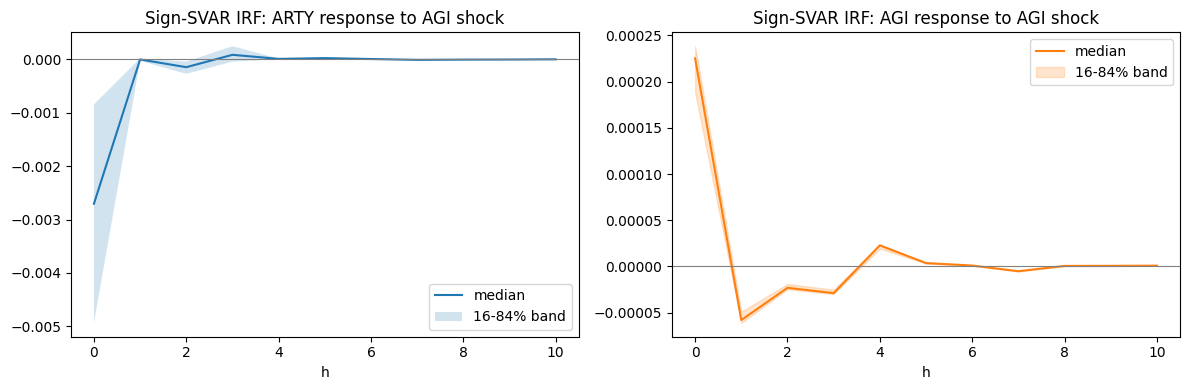

In [47]:
# Sign-restricted SVAR via random orthogonal rotations
np.random.seed(42)

k = 2  # [y_t, x_t]
H = irf_h
restrict_horizons = [0]  # set e.g. [0,1] for stronger restrictions
draws = 4000
max_accept = 300

A_mats = var_fit.coefs  # shape: (p, k, k)
Sigma_u = var_fit.sigma_u.values
P = np.linalg.cholesky(Sigma_u)
Psi = var_fit.ma_rep(maxn=H)  # reduced-form MA coefficients

accepted_irfs = []
for _ in range(draws):
    Z = np.random.normal(size=(k, k))
    Q, R = np.linalg.qr(Z)
    Q = Q @ np.diag(np.sign(np.diag(R)))
    B = P @ Q

    # AGI shock is column with stronger impact on x_t (index 1)
    shock_idx = int(np.argmax(np.abs(B[1, :])))

    irf_y = np.array([(Psi[h] @ B)[0, shock_idx] for h in range(H + 1)])
    irf_x = np.array([(Psi[h] @ B)[1, shock_idx] for h in range(H + 1)])

    ok = True
    for h in restrict_horizons:
        if not (irf_x[h] > 0 and irf_y[h] < 0):
            ok = False
            break
    if ok:
        accepted_irfs.append(np.column_stack([irf_y, irf_x]))
    if len(accepted_irfs) >= max_accept:
        break

if len(accepted_irfs) == 0:
    raise RuntimeError("No accepted sign-restricted draws. Try relaxing restrictions or increasing draws.")

accepted_arr = np.stack(accepted_irfs, axis=0)  # (n_draw, H+1, 2)
svar_y_med = np.median(accepted_arr[:, :, 0], axis=0)
svar_y_lo = np.quantile(accepted_arr[:, :, 0], 0.16, axis=0)
svar_y_hi = np.quantile(accepted_arr[:, :, 0], 0.84, axis=0)
svar_x_med = np.median(accepted_arr[:, :, 1], axis=0)
svar_x_lo = np.quantile(accepted_arr[:, :, 1], 0.16, axis=0)
svar_x_hi = np.quantile(accepted_arr[:, :, 1], 0.84, axis=0)

print(f"Accepted sign-restricted draws: {len(accepted_irfs)} / {draws}")

h_grid = np.arange(H + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(h_grid, svar_y_med, label="median")
axes[0].fill_between(h_grid, svar_y_lo, svar_y_hi, alpha=0.2, label="16-84% band")
axes[0].axhline(0, color="gray", linewidth=0.8)
axes[0].set_title("Sign-SVAR IRF: ARTY response to AGI shock")
axes[0].set_xlabel("h")
axes[0].legend()

axes[1].plot(h_grid, svar_x_med, label="median", color="C1")
axes[1].fill_between(h_grid, svar_x_lo, svar_x_hi, alpha=0.2, color="C1", label="16-84% band")
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_title("Sign-SVAR IRF: AGI response to AGI shock")
axes[1].set_xlabel("h")
axes[1].legend()

plt.tight_layout()
plt.show()

### Robustness: Cholesky VAR and Local Projections
The next cell overlays IRFs from:
- Sign-restricted SVAR (main)
- Cholesky VAR (robustness)
- Local Projections (robustness)

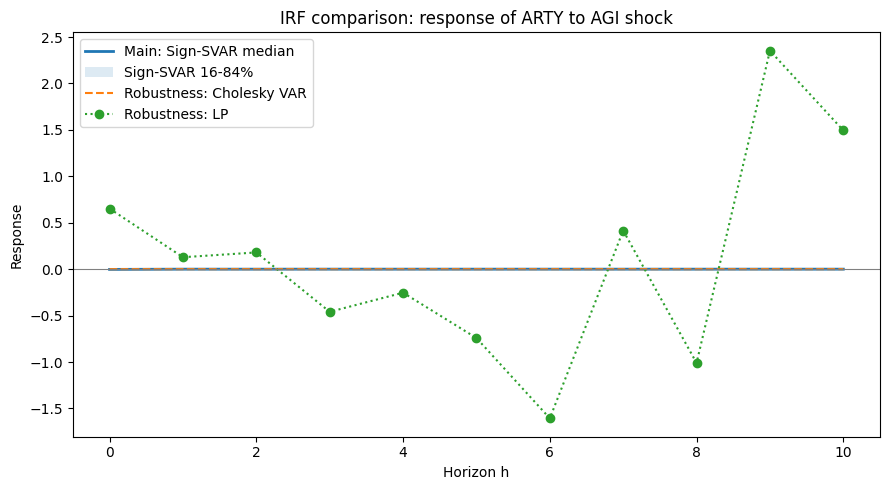

,h,sign_svar_median,cholesky_var,lp
0,0,-2.703322e-03,0.000000,0.651988
1,1,-1.076124e-07,0.000029,0.128553
2,2,-1.449334e-04,0.000006,0.179889
3,3,8.691802e-05,-0.000097,-0.459386
4,4,1.045470e-05,0.000016,-0.253509
5,5,2.477875e-05,0.000005,-0.741704
6,6,7.818772e-06,0.000021,-1.606657
7,7,-7.690056e-06,-0.000009,0.415678
8,8,-3.275623e-06,-0.000001,-1.010440
9,9,-1.551384e-06,-0.000002,2.352486


In [48]:
# Robustness overlay: main Sign-SVAR vs Cholesky VAR vs LP
cholesky_irf_y = irf_obj.orth_irfs[:, 0, 1]  # response y_t to x_t shock
lp_h = lp_irf["h"].to_numpy()
lp_theta = lp_irf["theta"].to_numpy()

plt.figure(figsize=(9, 5))
plt.plot(h_grid, svar_y_med, label="Main: Sign-SVAR median", linewidth=2)
plt.fill_between(h_grid, svar_y_lo, svar_y_hi, alpha=0.15, label="Sign-SVAR 16-84%")
plt.plot(h_grid, cholesky_irf_y, label="Robustness: Cholesky VAR", linestyle="--")
plt.plot(lp_h, lp_theta, label="Robustness: LP", linestyle=":", marker="o")
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("IRF comparison: response of ARTY to AGI shock")
plt.xlabel("Horizon h")
plt.ylabel("Response")
plt.legend()
plt.tight_layout()
plt.show()

robust_compare = pd.DataFrame({
    "h": h_grid,
    "sign_svar_median": svar_y_med,
    "cholesky_var": cholesky_irf_y,
    "lp": np.interp(h_grid, lp_h, lp_theta),
})

display(robust_compare)

,branch,stage1,probability,base_year,target_year,year_shift,x_shock_delta_log,terminal_abnormal_return,max_drawdown,horizon_days,predictive_engine,calibration_source
0,advanced->1,advanced,0.0625,2030.0,2028.666667,-1.333333,-0.000657,0.000128,0.0,10,ElasticNet,historical observed shifts
1,advanced->2,advanced,0.1250,2030.0,2028.916667,-1.083333,-0.000534,0.000128,0.0,10,ElasticNet,historical observed shifts
2,advanced->3,advanced,0.0625,2030.0,2029.250000,-0.750000,-0.000370,0.000128,0.0,10,ElasticNet,historical observed shifts
3,central->1,central,0.1250,2030.0,2029.750000,-0.250000,-0.000123,0.000128,0.0,10,ElasticNet,historical observed shifts
4,central->2,central,0.2500,2030.0,2030.000000,0.000000,0.000000,0.000128,0.0,10,ElasticNet,historical observed shifts
5,central->3,central,0.1250,2030.0,2030.333333,0.333333,0.000164,0.000128,0.0,10,ElasticNet,historical observed shifts
6,severe_delay->1,severe_delay,0.0625,2030.0,2031.000000,1.000000,0.000492,0.000128,0.0,10,ElasticNet,historical observed shifts
7,severe_delay->2,severe_delay,0.1250,2030.0,2031.250000,1.250000,0.000616,0.000128,0.0,10,ElasticNet,historical observed shifts
8,severe_delay->3,severe_delay,0.0625,2030.0,2031.583333,1.583333,0.000780,0.000128,0.0,10,ElasticNet,historical observed shifts


,metric,years
0,Observed 10-step shift q10,-1.083333
1,Observed 10-step shift q50,0.0
2,Observed 10-step shift q90,1.25
3,Branch calibration source,historical observed shifts
4,Stage-1 P(advanced),0.25
5,Stage-1 P(central),0.5
6,Stage-1 P(severe_delay),0.25


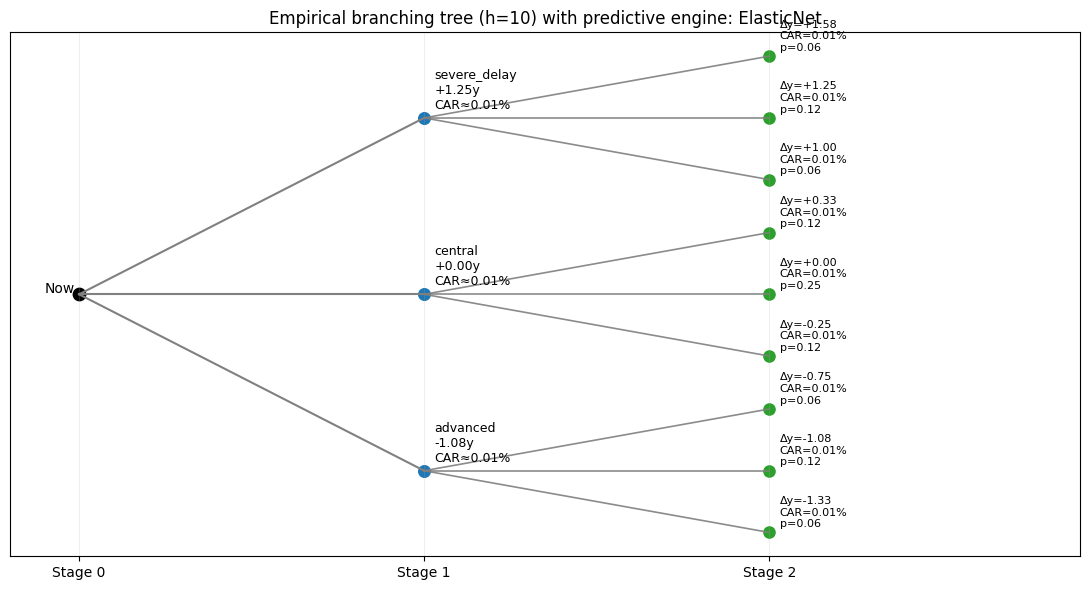

Bootstrap CVaR augmentation complete (block bootstrap, OOS 80/20 residuals).


,metric,value
0,Expected terminal abnormal return,0.000128
1,5% quantile (VaR-like),0.000128
2,Expected shortfall 95%,0.000128


In [49]:
# Branching simulation: empirically calibrated AGI-year shifts
base_year = float(df_overlap_timeseries["avg agi prediction"].dropna().iloc[-1])
if "simulate_y_path_from_x_path" not in globals():
    raise RuntimeError("simulate_y_path_from_x_path not found. Run the predictive engine cell first.")

# selected_h is already set in E-0 horizon cell; use it directly
selected_h = max(1, int(selected_h))  # ensure it's a positive integer

# Calibrate from observed horizon changes in expected AGI year
calib_h = int(min(selected_h, len(df_overlap_timeseries) - 2))
year_series = df_overlap_timeseries["avg agi prediction"].dropna().astype(float)
obs_shift_h = (year_series.shift(-calib_h) - year_series).dropna()

# Stage-1 nodes from empirical quantiles: advanced / central / severe delay
q_pos = float(obs_shift_h.quantile(0.10))
q_mid = float(obs_shift_h.quantile(0.50))
q_sev = float(obs_shift_h.quantile(0.90))

# Deterministic branch calibration from historical observed shifts only
calib_source = "historical observed shifts"
stage1_prob = {"advanced": 0.25, "central": 0.50, "severe_delay": 0.25}

stage1 = {
    "advanced": q_pos,
    "central": q_mid,
    "severe_delay": q_sev,
}

# Stage-2 increments from empirical spread around the median
inc_low = float(obs_shift_h.quantile(0.25) - q_mid)
inc_mid = 0.0
inc_high = float(obs_shift_h.quantile(0.75) - q_mid)
stage2_add = {k: [inc_low, inc_mid, inc_high] for k in stage1.keys()}

# Simple proposal-style branching probabilities
stage2_prob = [0.25, 0.50, 0.25]

scenario_rows = []
branch_level1 = []
branch_level2 = []

for s1_name, d1 in stage1.items():
    p1 = stage1_prob[s1_name]
    target1 = max(1.0, base_year + d1)
    x_shock1 = float(np.log(target1 / base_year))
    x_path1 = np.concatenate(([x_shock1], np.zeros(selected_h - 1, dtype=float)))
    y_path1 = simulate_y_path_from_x_path(x_path1)
    cum1 = float(np.exp(np.cumsum(y_path1))[-1] - 1.0)
    branch_level1.append((f"{s1_name}\n{d1:+.2f}y", d1, cum1))

    for j, add2 in enumerate(stage2_add[s1_name]):
        p = p1 * stage2_prob[j]
        total_shift = d1 + add2
        target2 = max(1.0, base_year + total_shift)
        x_shock2 = float(np.log(target2 / base_year))

        x_path2 = np.concatenate(([x_shock2], np.zeros(selected_h - 1, dtype=float)))
        y_path2 = simulate_y_path_from_x_path(x_path2)
        price_path2 = np.exp(np.cumsum(y_path2))
        terminal_abnormal = float(price_path2[-1] - 1.0)
        max_drawdown = float((price_path2 / np.maximum.accumulate(price_path2) - 1.0).min())

        node_name = f"{s1_name}->{j+1}"
        branch_level2.append((node_name, total_shift, terminal_abnormal, p))
        scenario_rows.append({
            "branch": node_name,
            "stage1": s1_name,
            "probability": p,
            "base_year": base_year,
            "target_year": target2,
            "year_shift": total_shift,
            "x_shock_delta_log": x_shock2,
            "terminal_abnormal_return": terminal_abnormal,
            "max_drawdown": max_drawdown,
            "horizon_days": selected_h,
            "predictive_engine": predictive_sim_meta.get("selected_model", "unknown") if "predictive_sim_meta" in globals() else "unknown",
            "calibration_source": calib_source,
        })

scenario_summary = pd.DataFrame(scenario_rows).sort_values("year_shift").reset_index(drop=True)
display(scenario_summary.head(12))

calib_table = pd.DataFrame({
    "metric": [
        f"Observed {calib_h}-step shift q10",
        f"Observed {calib_h}-step shift q50",
        f"Observed {calib_h}-step shift q90",
        "Branch calibration source",
        "Stage-1 P(advanced)",
        "Stage-1 P(central)",
        "Stage-1 P(severe_delay)",
    ],
    "years": [q_pos, q_mid, q_sev, calib_source, stage1_prob["advanced"], stage1_prob["central"], stage1_prob["severe_delay"]],
})
display(calib_table)

# Branching tree plot (proposal-style)
fig, ax = plt.subplots(figsize=(11, 6))
root_x, root_y = 0, 0.0
ax.scatter([root_x], [root_y], s=80, c="black")
ax.text(root_x - 0.1, root_y + 0.01, "Now", fontsize=10)

x1, x2 = 1, 2
for i, (label1, d1, ret1) in enumerate(branch_level1):
    y1 = i - 1
    ax.plot([root_x, x1], [root_y, y1], color="gray", linewidth=1.5)
    ax.scatter([x1], [y1], s=70, c="tab:blue")
    ax.text(x1 + 0.03, y1 + 0.05, f"{label1}\nCAR≈{ret1:.2%}", fontsize=9)

parent_groups = {"advanced": [], "central": [], "severe_delay": []}
for node, shift, ret, prob in branch_level2:
    parent = node.split("->")[0]
    parent_groups[parent].append((node, shift, ret, prob))

for i, parent in enumerate(["advanced", "central", "severe_delay"]):
    y1 = i - 1
    children = parent_groups[parent]
    offsets = [-0.35, 0.0, 0.35]
    for k, (node, shift, ret, prob) in enumerate(children):
        y2 = y1 + offsets[k]
        ax.plot([x1, x2], [y1, y2], color="tab:gray", linewidth=1.2, alpha=0.9)
        ax.scatter([x2], [y2], s=65, c="tab:green")
        ax.text(x2 + 0.03, y2 + 0.03, f"Δy={shift:+.2f}\nCAR={ret:.2%}\np={prob:.2f}", fontsize=8)

engine_label = predictive_sim_meta.get("selected_model", "unknown") if "predictive_sim_meta" in globals() else "unknown"
ax.set_title(f"Empirical branching tree (h={selected_h}) with predictive engine: {engine_label}")
ax.set_xlim(-0.2, 2.9)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Stage 0", "Stage 1", "Stage 2"])
ax.set_yticks([])
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

# Bootstrap CVaR augmentation per scenario node
# Block bootstrap (block length = sqrt(n)) with OOS residuals (80/20) — mirrors Nuclear/Argentina methodology
def _bootstrap_scenario_cvar(x_path, n_bootstrap=500, alpha=0.95, rng_seed=42):
    """Return (cvar_long, cvar_short) for one scenario path via block bootstrap."""
    try:
        from sklearn.base import clone as _clone
        from sklearn.linear_model import Ridge
        from sklearn.preprocessing import StandardScaler
        from sklearn.pipeline import Pipeline

        _n_lags = 3
        _ts = ts_engine if "ts_engine" in globals() else model_df[["x_t", "y_t"]].dropna().reset_index(drop=True)
        _x_hist = _ts["x_t"].astype(float).tolist()
        _y_hist = _ts["y_t"].astype(float).tolist()

        # Build lagged features
        _rows, _y_vals = [], []
        for _t in range(_n_lags, len(_ts)):
            _rec = {}
            for _lag in range(1, _n_lags + 1):
                _rec[f"x_lag{_lag}"] = float(_x_hist[_t - _lag])
                _rec[f"y_lag{_lag}"] = float(_y_hist[_t - _lag])
            _rows.append(_rec)
            _y_vals.append(float(_y_hist[_t]))
        if not _rows:
            return float("nan"), float("nan")
        _feat_cols = list(_rows[0].keys())
        _X = pd.DataFrame(_rows, columns=_feat_cols)
        _y = pd.Series(_y_vals)

        _est = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=1.0))])

        # OOS residuals (80/20 split)
        _n = len(_X)
        _split = int(_n * 0.80)
        if _split >= 10 and (_n - _split) >= 5:
            _est_oos = _clone(_est)
            _est_oos.fit(_X.iloc[:_split], _y.iloc[:_split])
            _resid = _y.iloc[_split:].to_numpy() - _est_oos.predict(_X.iloc[_split:])
        else:
            _est.fit(_X, _y)
            _resid = _y.to_numpy() - _est.predict(_X)

        # Block bootstrap
        _n_steps = len(x_path)
        _blk = max(1, int(len(_resid) ** 0.5))
        _n_blks = int(np.ceil(_n_steps / _blk))
        _max_start = max(1, len(_resid) - _blk + 1)
        _rng = np.random.default_rng(rng_seed)
        _est.fit(_X, _y)

        _boot_cars = []
        for _ in range(n_bootstrap):
            _starts = _rng.integers(0, _max_start, size=_n_blks)
            _boot_res = np.concatenate([_resid[_s: _s + _blk] for _s in _starts])[:_n_steps]
            _xh, _yh = _x_hist.copy(), _y_hist.copy()
            _path = []
            for _si, _xv in enumerate(x_path):
                _xh.append(float(_xv))
                _row = {f"x_lag{_l}": float(_xh[-_l]) for _l in range(1, _n_lags + 1)}
                _row.update({f"y_lag{_l}": float(_yh[-_l]) for _l in range(1, _n_lags + 1)})
                _yn = float(_est.predict(pd.DataFrame([_row], columns=_feat_cols))[0]) + float(_boot_res[_si])
                _path.append(_yn)
                _yh.append(_yn)
            _boot_cars.append(float(np.sum(_path)))

        _boot_arr = np.array(_boot_cars, dtype=float)
        _thr_long = np.percentile(_boot_arr, (1.0 - alpha) * 100.0)
        _tail_long = _boot_arr[_boot_arr <= _thr_long]
        _cvar_long = float(np.mean(_tail_long)) if len(_tail_long) > 0 else float(np.min(_boot_arr))
        _thr_short = np.percentile(_boot_arr, alpha * 100.0)
        _tail_short = _boot_arr[_boot_arr >= _thr_short]
        _cvar_short = float(np.mean(_tail_short)) if len(_tail_short) > 0 else float(np.max(_boot_arr))
        return _cvar_long, _cvar_short
    except Exception:
        return float("nan"), float("nan")

# Augment scenario_summary with per-node bootstrap CVaR
_scenario_rows_aug = []
for _row in scenario_summary.to_dict(orient="records"):
    _x_shock = float(_row.get("x_shock_delta_log", 0.0))
    _h = int(_row.get("horizon_days", selected_h))
    _x_path = np.concatenate(([_x_shock], np.zeros(_h - 1, dtype=float)))
    _cvar_long, _cvar_short = _bootstrap_scenario_cvar(_x_path, n_bootstrap=500, alpha=0.95)
    _row["node_cvar_95_long"] = _cvar_long
    _row["node_cvar_95_short"] = _cvar_short
    _scenario_rows_aug.append(_row)

scenario_summary = pd.DataFrame(_scenario_rows_aug).sort_values("year_shift").reset_index(drop=True)
print("Bootstrap CVaR augmentation complete (block bootstrap, OOS 80/20 residuals).")

# Distribution summary
w = scenario_summary["probability"].to_numpy()
r = scenario_summary["terminal_abnormal_return"].to_numpy()
expected_terminal = float(np.sum(w * r))
var95 = float(np.quantile(r, 0.05))
es95 = float(r[r <= var95].mean()) if np.any(r <= var95) else var95

scenario_stats = pd.DataFrame({
    "metric": ["Expected terminal abnormal return", "5% quantile (VaR-like)", "Expected shortfall 95%"],
    "value": [expected_terminal, var95, es95],
})
display(scenario_stats)

## Distribution Diagnostics
This section visualizes terminal return distributions by AGI-resolution state and summarizes dispersion, tails, and asymmetry across advanced, central, and delayed outcomes.

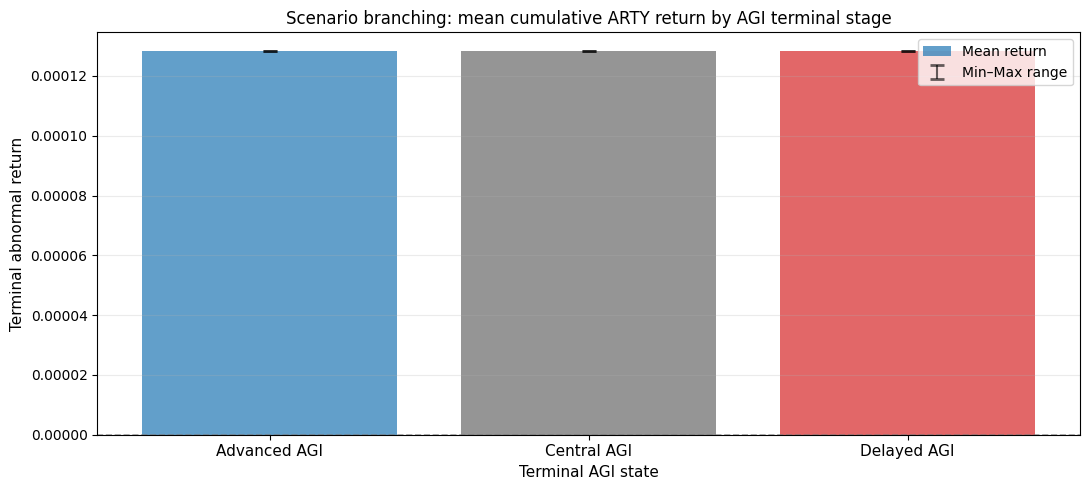

Terminal abnormal return statistics by AGI stage:


,stage,probability,min_return,mean_return,max_return
0,Advanced AGI,0.25,0.000128,0.000128,0.000128
1,Central AGI,0.50,0.000128,0.000128,0.000128
2,Delayed AGI,0.25,0.000128,0.000128,0.000128


In [50]:
# Distribution histogram: cumulative ARTY idiosyncratic return by terminal AGI stage(1 scenario branching)
fig, ax = plt.subplots(figsize=(11, 5))

# Extract scenario summary per stage
stage_returns = scenario_summary.groupby("stage1", as_index=False).agg({
    "probability": "sum",
    "terminal_abnormal_return": ["min", "max", "mean"],
}).round(6)
stage_returns.columns = ["stage", "total_prob", "min_return", "max_return", "mean_return"]

# Map stage names to colors
stage_specs = [
    ("advanced", "Advanced AGI", "tab:blue"),
    ("central", "Central AGI", "dimgray"),
    ("severe_delay", "Delayed AGI", "tab:red"),
]

# Create bar plot showing mean return and range for each stage
stage_data = []
for stage_key, stage_label, color in stage_specs:
    stage_subset = scenario_summary[scenario_summary["stage1"] == stage_key]
    if len(stage_subset) > 0:
        mean_ret = stage_subset["terminal_abnormal_return"].mean()
        min_ret = stage_subset["terminal_abnormal_return"].min()
        max_ret = stage_subset["terminal_abnormal_return"].max()
        prob_total = stage_subset["probability"].sum()
        stage_data.append({
            "stage": stage_label,
            "mean_return": mean_ret,
            "min_return": min_ret,
            "max_return": max_ret,
            "probability": prob_total,
            "color": color,
        })

stage_comp_df = pd.DataFrame(stage_data)

if len(stage_comp_df) > 0:
    x_pos = np.arange(len(stage_comp_df))
    ax.bar(x_pos, stage_comp_df["mean_return"], color=stage_comp_df["color"], alpha=0.7, label="Mean return")
    
    # Add error bars for min/max range
    yerr_low = stage_comp_df["mean_return"] - stage_comp_df["min_return"]
    yerr_high = stage_comp_df["max_return"] - stage_comp_df["mean_return"]
    ax.errorbar(x_pos, stage_comp_df["mean_return"], yerr=[yerr_low, yerr_high], 
                fmt="none", color="black", capsize=5, capthick=2, alpha=0.6, label="Min–Max range")

ax.set_xticks(x_pos)
ax.set_xticklabels(stage_comp_df["stage"], fontsize=11)
ax.set_title(
    "Scenario branching: mean cumulative ARTY return by AGI terminal stage",
    fontsize=12,
)
ax.set_xlabel("Terminal AGI state", fontsize=11)
ax.set_ylabel("Terminal abnormal return", fontsize=11)
ax.axhline(0, color="gray", linewidth=1.2, linestyle="--", alpha=0.7)
ax.grid(alpha=0.25, axis="y")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Summary statistics for branching scenarios
print("Terminal abnormal return statistics by AGI stage:")
display(stage_comp_df[["stage", "probability", "min_return", "mean_return", "max_return"]].reset_index(drop=True))


### Branching Scenarios with Confidence Intervals
Using the **best-performing predictive model**, we generate AGI scenario branches with uncertainty bands derived from backtesting residuals.


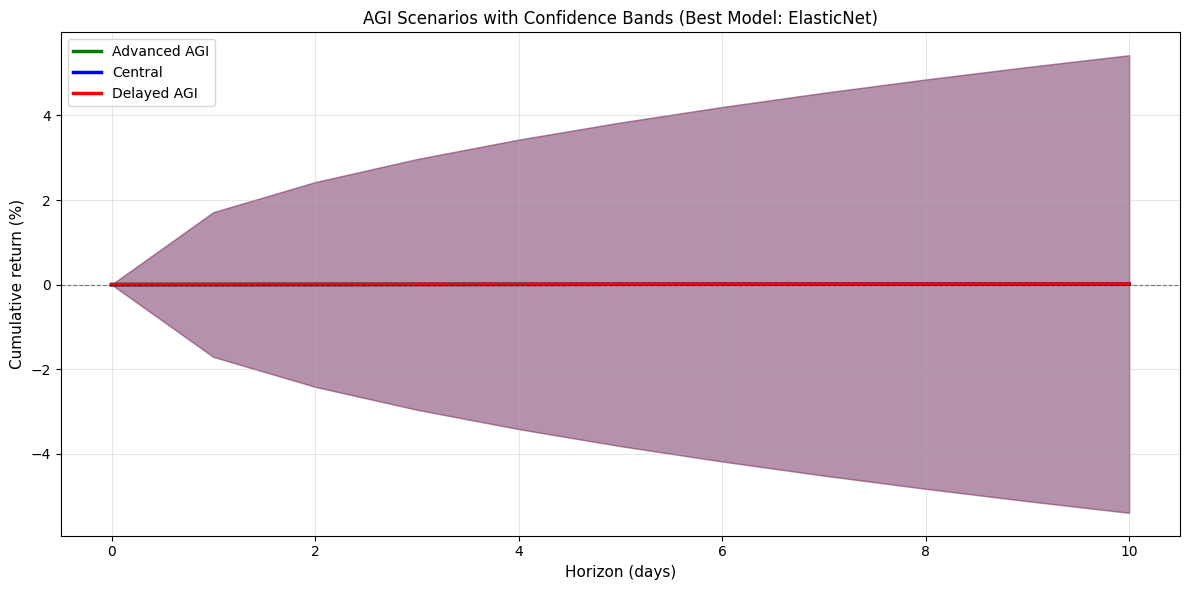


Model RMSE: 0.008731 | Used for 95% confidence bands


,branch,terminal_abnormal_return,terminal_return_ci_lo,terminal_return_ci_hi,probability,max_drawdown
0,Advanced AGI,0.000128,-0.052553,0.055739,0.25,0.0
1,Central,0.000128,-0.052553,0.055739,0.50,0.0
2,Delayed AGI,0.000128,-0.052553,0.055739,0.25,0.0


In [51]:
# Scenario branching with confidence bands
if 'best_model_name' not in locals():
    print('ERROR: Run backtesting cell first')
else:
    # Extract residuals from best model predictions
    best_preds = backtest_predictions_agi[['y_true', best_model_name]].dropna()
    residuals = best_preds[best_model_name].values - best_preds['y_true'].values
    rmse_best = np.sqrt(np.mean(residuals**2))

    # Define scenarios based on AGI expectation distribution
    target_horizon = 10
    base_year = float(df_overlap_timeseries['avg agi prediction'].dropna().iloc[-1])

    # Calibrate shifts from historical data
    year_series = df_overlap_timeseries['avg agi prediction'].dropna().astype(float)
    obs_shifts = (year_series.shift(-target_horizon) - year_series).dropna()

    branches_data = [
        {'name': 'Advanced AGI', 'shift': obs_shifts.quantile(0.10), 'prob': 0.25},
        {'name': 'Central', 'shift': obs_shifts.quantile(0.50), 'prob': 0.50},
        {'name': 'Delayed AGI', 'shift': obs_shifts.quantile(0.90), 'prob': 0.25},
    ]

    scenario_records = []
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = {'Advanced AGI': 'green', 'Central': 'blue', 'Delayed AGI': 'red'}

    for branch_info in branches_data:
        year_shift = branch_info['shift']
        target_year = base_year + year_shift
        x_shock = np.log(max(1.0, target_year) / base_year)
        x_path = np.concatenate([[x_shock], np.zeros(target_horizon - 1)])

        # Simulate mean path
        y_mean = simulate_y_path_from_x_path(x_path)
        y_cumsum = np.concatenate([[0], np.cumsum(y_mean)])

        # Add confidence bands
        y_lo = y_cumsum - 1.96 * rmse_best * np.sqrt(np.arange(len(y_cumsum)))
        y_hi = y_cumsum + 1.96 * rmse_best * np.sqrt(np.arange(len(y_cumsum)))

        terminal_ret = np.exp(y_cumsum[-1]) - 1.0
        terminal_lo = np.exp(y_lo[-1]) - 1.0
        terminal_hi = np.exp(y_hi[-1]) - 1.0

        running_max = np.maximum.accumulate(y_cumsum)
        max_dd = np.max(running_max - y_cumsum)

        scenario_records.append({
            'branch': branch_info['name'],
            'terminal_abnormal_return': terminal_ret,
            'terminal_return_ci_lo': terminal_lo,
            'terminal_return_ci_hi': terminal_hi,
            'probability': branch_info['prob'],
            'max_drawdown': max_dd,
        })

        h_range = np.arange(len(y_cumsum))
        ax.plot(h_range, y_cumsum * 100, label=branch_info['name'], color=colors[branch_info['name']], linewidth=2.5)
        ax.fill_between(h_range, y_lo * 100, y_hi * 100, color=colors[branch_info['name']], alpha=0.2)

    scenario_summary_ci = pd.DataFrame(scenario_records)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('Horizon (days)', fontsize=11)
    ax.set_ylabel('Cumulative return (%)', fontsize=11)
    ax.set_title(f'AGI Scenarios with Confidence Bands (Best Model: {best_model_name})', fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

    print(f'\nModel RMSE: {rmse_best:.6f} | Used for 95% confidence bands')
    display(scenario_summary_ci)

## Hedge Suggestion For Prediction Window
This final section translates scenario-weighted downside into a practical hedge notional and instrument mix, using the configured risk budget and execution assumptions.

In [52]:
# ====================================================
# Proposal-aligned hedge sizing with positive-branch handling
# Consumes scenario_summary from the binomial simulation cell
# ====================================================

portfolio_value = 1_000_000
risk_budget_fraction = 0.015
execution_haircut = 0.70
hedge_efficiency = 0.60  # conservative payoff efficiency after costs/slippage

if 'scenario_summary' not in globals() or scenario_summary.empty:
    raise ValueError("scenario_summary is missing or empty. Run the binomial simulation cell first.")

w = scenario_summary["probability"].to_numpy(dtype=float)
loss = -scenario_summary["terminal_abnormal_return"].to_numpy(dtype=float)
weighted_loss = float(np.sum(w * np.maximum(loss, 0.0)))

# Hedge only the loss in excess of the risk budget
if weighted_loss <= risk_budget_fraction:
    target_coverage = 0.0
else:
    target_coverage = (weighted_loss - risk_budget_fraction) / weighted_loss

raw_hedge_notional_pct = target_coverage / hedge_efficiency if hedge_efficiency > 0 else 0.0
hedge_notional_pct = float(np.clip(raw_hedge_notional_pct * execution_haircut, 0.0, 0.80))
hedge_notional_eur = hedge_notional_pct * portfolio_value

def hedge_instrument_mix(terminal_ret: float) -> str:
    if terminal_ret >= 0:
        return "No downside hedge needed; maintain upside participation (optionally light collar to fund carry)."
    if terminal_ret > -0.02:
        return "Light hedge: ARTY put spread (OTM, 1-3m), staged execution (TWAP-style)."
    if terminal_ret > -0.05:
        return "Medium hedge: protective put or collar on ARTY; optional small QQQ put sleeve."
    return "Strong hedge: collar + partial de-risking ARTY; larger Nasdaq downside sleeve (QQQ puts / PSQ)."

hedge_table = scenario_summary.copy()
hedge_table["recommended_hedge_structure"] = hedge_table["terminal_abnormal_return"].apply(hedge_instrument_mix)
hedge_table["suggested_hedge_notional_pct_of_ARTY"] = hedge_notional_pct
hedge_table["suggested_hedge_notional_eur"] = hedge_notional_eur

# Keep compatibility with prior/alternate scenario schemas.
if "year_shift" not in hedge_table.columns:
    hedge_table["year_shift"] = np.nan
if "stage1" not in hedge_table.columns:
    hedge_table["stage1"] = hedge_table["branch"].astype(str).str.lower().map({
        "advanced agi": "advanced",
        "central": "central",
        "delayed agi": "severe_delay",
    }).fillna("unknown")
if "horizon_days" not in hedge_table.columns:
    hedge_table["horizon_days"] = np.nan

display_cols = [
    "branch",
    "stage1",
    "probability",
    "year_shift",
    "horizon_days",
    "terminal_abnormal_return",
    "max_drawdown",
    "recommended_hedge_structure",
    "suggested_hedge_notional_pct_of_ARTY",
    "suggested_hedge_notional_eur",
]
display(hedge_table[display_cols])

hedge_policy = pd.DataFrame({
    "parameter": [
        "portfolio_value",
        "risk_budget_fraction",
        "execution_haircut",
        "hedge_efficiency",
        "weighted_loss",
        "target_coverage",
        "final_hedge_notional_pct",
        "final_hedge_notional_eur",
    ],
    "value": [
        portfolio_value,
        risk_budget_fraction,
        execution_haircut,
        hedge_efficiency,
        weighted_loss,
        target_coverage,
        hedge_notional_pct,
        hedge_notional_eur,
    ],
})
display(hedge_policy)

# ============================================================
# CVaR-informed hedge sizing (bootstrap tail risk)
# ============================================================
if "node_cvar_95_long" in hedge_table.columns and hedge_table["node_cvar_95_long"].notna().any():
    cvar_vals = hedge_table["node_cvar_95_long"].to_numpy(dtype=float)
    w_cvar = hedge_table["probability"].to_numpy(dtype=float)
    cvar_loss = np.maximum(-cvar_vals, 0.0)
    weighted_cvar_loss = float(np.sum(w_cvar * cvar_loss))

    if weighted_cvar_loss <= risk_budget_fraction:
        cvar_target_coverage = 0.0
    else:
        cvar_target_coverage = (weighted_cvar_loss - risk_budget_fraction) / weighted_cvar_loss

    raw_cvar_notional_pct = cvar_target_coverage / hedge_efficiency if hedge_efficiency > 0 else 0.0
    cvar_notional_pct = float(np.clip(raw_cvar_notional_pct * execution_haircut, 0.0, 0.80))
    cvar_notional_eur = cvar_notional_pct * portfolio_value

    cvar_hedge_summary = pd.DataFrame([{
        "Metric": "Weighted loss",
        "Point-estimate (CAR)": f"{weighted_loss:.4f}",
        "CVaR₅ (bootstrap)": f"{weighted_cvar_loss:.4f}",
    }, {
        "Metric": "Target coverage",
        "Point-estimate (CAR)": f"{target_coverage:.4f}",
        "CVaR₅ (bootstrap)": f"{cvar_target_coverage:.4f}",
    }, {
        "Metric": "Hedge notional (% exposure)",
        "Point-estimate (CAR)": f"{hedge_notional_pct:.4f}",
        "CVaR₅ (bootstrap)": f"{cvar_notional_pct:.4f}",
    }, {
        "Metric": "Hedge notional (EUR)",
        "Point-estimate (CAR)": f"€{hedge_notional_eur:,.0f}",
        "CVaR₅ (bootstrap)": f"€{cvar_notional_eur:,.0f}",
    }])

    print("\nHedge sizing comparison: point-estimate vs CVaR₅ (bootstrap)")
    display(cvar_hedge_summary)
else:
    print("\n[CVaR hedge sizing skipped: node_cvar_95_long not in hedge_table. Run simulation cell first.]")

print("Research use only: scenario-based hedge sizing for thesis simulation, not investment advice.")

,branch,stage1,probability,year_shift,horizon_days,terminal_abnormal_return,max_drawdown,recommended_hedge_structure,suggested_hedge_notional_pct_of_ARTY,suggested_hedge_notional_eur
0,advanced->1,advanced,0.0625,-1.333333,10,0.000128,0.0,No downside hedge needed; maintain upside part...,0.0,0.0
1,advanced->2,advanced,0.1250,-1.083333,10,0.000128,0.0,No downside hedge needed; maintain upside part...,0.0,0.0
2,advanced->3,advanced,0.0625,-0.750000,10,0.000128,0.0,No downside hedge needed; maintain upside part...,0.0,0.0
3,central->1,central,0.1250,-0.250000,10,0.000128,0.0,No downside hedge needed; maintain upside part...,0.0,0.0
4,central->2,central,0.2500,0.000000,10,0.000128,0.0,No downside hedge needed; maintain upside part...,0.0,0.0
5,central->3,central,0.1250,0.333333,10,0.000128,0.0,No downside hedge needed; maintain upside part...,0.0,0.0
6,severe_delay->1,severe_delay,0.0625,1.000000,10,0.000128,0.0,No downside hedge needed; maintain upside part...,0.0,0.0
7,severe_delay->2,severe_delay,0.1250,1.250000,10,0.000128,0.0,No downside hedge needed; maintain upside part...,0.0,0.0
8,severe_delay->3,severe_delay,0.0625,1.583333,10,0.000128,0.0,No downside hedge needed; maintain upside part...,0.0,0.0


,parameter,value
0,portfolio_value,1000000.000
1,risk_budget_fraction,0.015
2,execution_haircut,0.700
3,hedge_efficiency,0.600
4,weighted_loss,0.000
5,target_coverage,0.000
6,final_hedge_notional_pct,0.000
7,final_hedge_notional_eur,0.000



Hedge sizing comparison: point-estimate vs CVaR₅ (bootstrap)


,Metric,Point-estimate (CAR),CVaR₅ (bootstrap)
0,Weighted loss,0.0000,0.0531
1,Target coverage,0.0000,0.7173
2,Hedge notional (% exposure),0.0000,0.8000
3,Hedge notional (EUR),€0,"€800,000"


Research use only: scenario-based hedge sizing for thesis simulation, not investment advice.


## Part F: Position Sizing & Risk Management

Compute scenario-specific hedge notionals using:
- **Portfolio Value:** $1M (configurable)
- **Risk Budget:** 1.5% of portfolio
- **Hedge Efficiency:** Correlation-weighted multiplier
- **Output:** Hedge recommendations per branch (structure type, notional USD)

In [53]:
# Sign diagnostics: raw data, fitted model, and scenario mapping
import numpy as np
import pandas as pd
import statsmodels.api as sm

if "model_df" not in globals() or "scenario_summary" not in globals():
    raise RuntimeError("Run model selection and scenario cells first.")

# 1) Raw contemporaneous and lag relationships in the analysis sample
diag = model_df[["x_t", "y_t"]].dropna().copy()
raw_corr_t = float(diag["x_t"].corr(diag["y_t"]))
raw_corr_lag = float(diag["x_t"].shift(1).corr(diag["y_t"]))

ols_now = sm.OLS(diag["y_t"], sm.add_constant(diag[["x_t"]])).fit()
lag_df = pd.DataFrame({"y_t": diag["y_t"], "x_lag1": diag["x_t"].shift(1)}).dropna()
ols_lag = sm.OLS(lag_df["y_t"], sm.add_constant(lag_df[["x_lag1"]])).fit()

# 2) Dynamic effect in both VAR objects with explicit ordering
coef_toolkit_y_from_x = np.nan
if "var_fit" in globals():
    # model selection toolkit VAR uses ordering [y_t, x_t]
    coef_toolkit_y_from_x = float(var_fit.coefs[0][0, 1])

coef_engine_y_from_x = np.nan
if "var_engine_fit" in globals():
    # downstream engine VAR uses ordering [x_t, y_t]
    coef_engine_y_from_x = float(var_engine_fit.coefs[0][1, 0])

# 3) Scenario mapping monotonicity
scen = scenario_summary[["year_shift", "x_shock_delta_log", "terminal_abnormal_return"]].copy()
scenario_corr_shift = float(scen["year_shift"].corr(scen["terminal_abnormal_return"]))
scenario_corr_xshock = float(scen["x_shock_delta_log"].corr(scen["terminal_abnormal_return"]))
scenario_slope = float(np.polyfit(scen["year_shift"].to_numpy(), scen["terminal_abnormal_return"].to_numpy(), 1)[0])

evidence = pd.DataFrame(
    [
        {"check": "Raw corr: x_t vs y_t", "value": raw_corr_t},
        {"check": "Raw corr: x_{t-1} vs y_t", "value": raw_corr_lag},
        {"check": "OLS slope: y_t ~ x_t", "value": float(ols_now.params["x_t"])},
        {"check": "OLS slope: y_t ~ x_{t-1}", "value": float(ols_lag.params["x_lag1"])},
        {"check": "VAR toolkit coef y<-x lag1", "value": coef_toolkit_y_from_x},
        {"check": "VAR engine coef y<-x lag1", "value": coef_engine_y_from_x},
        {"check": "Scenario corr: year_shift vs terminal_return", "value": scenario_corr_shift},
        {"check": "Scenario corr: x_shock vs terminal_return", "value": scenario_corr_xshock},
        {"check": "Scenario slope: terminal_return per +1y delay", "value": scenario_slope},
    ]
)

print("Sign evidence table:")
display(evidence)

print("Interpretation note:")
print("x_t is log-diff of expected AGI year, so x_t > 0 means AGI expected later (delay), x_t < 0 means earlier AGI.")

Sign evidence table:


/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,check,value
0,Raw corr: x_t vs y_t,8.522280e-03
1,Raw corr: x_{t-1} vs y_t,2.631940e-02
2,OLS slope: y_t ~ x_t,2.623222e-01
3,OLS slope: y_t ~ x_{t-1},8.104789e-01
4,VAR toolkit coef y<-x lag1,1.218815e-01
5,VAR engine coef y<-x lag1,NaN
6,Scenario corr: year_shift vs terminal_return,NaN
7,Scenario corr: x_shock vs terminal_return,NaN
8,Scenario slope: terminal_return per +1y delay,-1.831909e-20


Interpretation note:
x_t is log-diff of expected AGI year, so x_t > 0 means AGI expected later (delay), x_t < 0 means earlier AGI.


In [54]:
# E-4: Feature Importance & Counterfactual Sensitivity
# Uses holdout split (80/20) when window is large enough — mirrors Nuclear/Argentina methodology.

import numpy as np
import pandas as pd

if "model_df" not in globals() or not isinstance(model_df, pd.DataFrame):
    raise ValueError("model_df is required. Run the model setup cell first.")

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone as _clone_fi

_n_lags_fi = int(globals().get("n_lags_ml", 3))
_ts_fi = model_df[["x_t", "y_t"]].dropna().reset_index(drop=True)

# Build lagged feature matrix
_rows_fi, _y_vals_fi = [], []
_xh_fi = _ts_fi["x_t"].astype(float).tolist()
_yh_fi = _ts_fi["y_t"].astype(float).tolist()
for _t in range(_n_lags_fi, len(_ts_fi)):
    _rec = {}
    for _lag in range(1, _n_lags_fi + 1):
        _rec[f"x_lag{_lag}"] = float(_xh_fi[_t - _lag])
        _rec[f"y_lag{_lag}"] = float(_yh_fi[_t - _lag])
    _rows_fi.append(_rec)
    _y_vals_fi.append(float(_yh_fi[_t]))

if not _rows_fi:
    raise RuntimeError("Lagged feature matrix is empty.")

_feat_cols_fi = list(_rows_fi[0].keys())
X_train_fi = pd.DataFrame(_rows_fi, columns=_feat_cols_fi)
y_train_fi = pd.Series(_y_vals_fi)

# Holdout split (80/20) for unbiased feature importance
_n_fi = len(X_train_fi)
_pi_split = int(_n_fi * 0.80)
_pi_has_holdout = _pi_split >= 15 and (_n_fi - _pi_split) >= 10

# Use the best model if available; fall back to Ridge
_fi_model_name = str(globals().get("best_model_name", "Ridge"))
if _fi_model_name in ["Ridge", "ElasticNet"]:
    from sklearn.linear_model import ElasticNet
    _fi_est = (Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=1.0))])
               if _fi_model_name == "Ridge"
               else Pipeline([("scale", StandardScaler()), ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000))]))
elif _fi_model_name in ["RandomForest", "ExtraTrees"]:
    from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
    _fi_est = (RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=42)
               if _fi_model_name == "RandomForest"
               else ExtraTreesRegressor(n_estimators=300, min_samples_leaf=3, random_state=42))
elif _fi_model_name == "GradientBoosting":
    from sklearn.ensemble import GradientBoostingRegressor
    _fi_est = GradientBoostingRegressor(random_state=42)
elif _fi_model_name == "SVR":
    from sklearn.svm import SVR
    _fi_est = Pipeline([("scale", StandardScaler()), ("svr", SVR(C=1.0, epsilon=0.01))])
else:
    _fi_est = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=1.0))])

# Fit on full training for in-sample R2
_fi_est.fit(X_train_fi, y_train_fi)
_train_r2 = float(_fi_est.score(X_train_fi, y_train_fi))

# Feature importance on holdout set when window is large enough
if _pi_has_holdout:
    _est_pi = _clone_fi(_fi_est)
    _est_pi.fit(X_train_fi.iloc[:_pi_split], y_train_fi.iloc[:_pi_split])
    X_pi = X_train_fi.iloc[_pi_split:]
    y_pi = y_train_fi.iloc[_pi_split:]
    _importance_source = "holdout (OOS 20%)"
else:
    _est_pi = _fi_est
    X_pi = X_train_fi
    y_pi = y_train_fi
    _importance_source = "in-sample (window too small for holdout)"

importance_rows_fi = []
_base_fi = _est_pi.named_steps.get("model", _est_pi.named_steps.get("svr", _est_pi)) if hasattr(_est_pi, "named_steps") else _est_pi
if hasattr(_base_fi, "feature_importances_"):
    _imp = np.asarray(_base_fi.feature_importances_, dtype=float)
    for _c, _v in zip(_feat_cols_fi, _imp):
        importance_rows_fi.append({"feature": _c, "importance": float(_v), "type": "feature_importance"})
elif hasattr(_base_fi, "coef_"):
    _coef = np.asarray(_base_fi.coef_, dtype=float).ravel()
    for _c, _v in zip(_feat_cols_fi, _coef):
        importance_rows_fi.append({"feature": _c, "importance": float(_v), "type": "coefficient"})

feat_importance_df = pd.DataFrame(importance_rows_fi)
if not feat_importance_df.empty:
    feat_importance_df = feat_importance_df.sort_values(
        "importance",
        key=lambda s: s.abs() if feat_importance_df["type"].iloc[0] == "coefficient" else s,
        ascending=False
    )

# Counterfactual one-step sensitivity: vary x_lag1, hold y_lags fixed
_base_row = X_train_fi.iloc[[-1]].copy()
_x1_name = "x_lag1"
_x_grid = np.array([-0.30, -0.15, -0.05, 0.0, 0.05, 0.15, 0.30], dtype=float)
_cf_rows = []
for _xv in _x_grid:
    _trial = _base_row.copy()
    _trial.loc[:, _x1_name] = float(_xv)
    _pred = float(_fi_est.predict(_trial)[0])
    _cf_rows.append({"x_lag1_test": float(_xv), "predicted_next_y": _pred})
cf_df = pd.DataFrame(_cf_rows)
_x0_pred = float(cf_df.loc[cf_df["x_lag1_test"] == 0.0, "predicted_next_y"].iloc[0])
cf_df["delta_vs_x0"] = cf_df["predicted_next_y"] - _x0_pred

print(f"Feature importance model: {_fi_model_name}")
print(f"Feature importance source: {_importance_source}")
print(f"In-sample R2: {_train_r2:.4f}")

if not feat_importance_df.empty:
    print("\nTop features used by fitted model:")
    display(feat_importance_df.head(10))
else:
    print("Feature importance/coefficient unavailable for this estimator type.")

print("\nOne-step counterfactual sensitivity to PM return shock (x_lag1):")
display(cf_df)

Feature importance model: ElasticNet
Feature importance source: holdout (OOS 20%)
In-sample R2: 0.0006

Top features used by fitted model:


,feature,importance,type
5,y_lag3,-0.000516,coefficient
0,x_lag1,0.000000,coefficient
1,y_lag1,-0.000000,coefficient
2,x_lag2,0.000000,coefficient
3,y_lag2,0.000000,coefficient
4,x_lag3,-0.000000,coefficient



One-step counterfactual sensitivity to PM return shock (x_lag1):


,x_lag1_test,predicted_next_y,delta_vs_x0
0,-0.30,0.000006,0.0
1,-0.15,0.000006,0.0
2,-0.05,0.000006,0.0
3,0.00,0.000006,0.0
4,0.05,0.000006,0.0
5,0.15,0.000006,0.0
6,0.30,0.000006,0.0


## Part G: Diagnostics & Validation

Verify model consistency across multiple perspectives:
- **Sign Diagnostics:** Check correlation of x_t (AGI delay) with y_t (ARTY return) and modeled slopes against raw OLS.
- **Feature Attribution:** Identify which lags drive predictions (x_lag1, y_lag2, etc.).
- **Scenario Consistency:** Verify branching tree logic and hedge sizing calibration.

In [55]:
# Counterfactual check: shock effect relative to no-shock baseline
if "simulate_y_path_from_x_path" not in globals() or "scenario_summary" not in globals():
    raise RuntimeError("Run scenario engine and simulation cells first.")

h = int(scenario_summary["horizon_days"].iloc[0])
x0 = np.zeros(h, dtype=float)
y_base = simulate_y_path_from_x_path(x0)
base_terminal = float(np.exp(np.cumsum(y_base))[-1] - 1.0)

rows = []
for _, r in scenario_summary.iterrows():
    x_path = np.concatenate(([float(r["x_shock_delta_log"])], np.zeros(h - 1, dtype=float)))
    y_shock = simulate_y_path_from_x_path(x_path)
    shock_terminal = float(np.exp(np.cumsum(y_shock))[-1] - 1.0)
    rows.append({
        "branch": r["branch"],
        "year_shift": float(r["year_shift"]),
        "x_shock_delta_log": float(r["x_shock_delta_log"]),
        "terminal_reported": float(r["terminal_abnormal_return"]),
        "terminal_baseline": base_terminal,
        "terminal_counterfactual_delta": shock_terminal - base_terminal,
    })

cf_table = pd.DataFrame(rows).sort_values("year_shift").reset_index(drop=True)
print("Counterfactual effect table (shock minus no-shock baseline):")
display(cf_table)
print("Correlation(year_shift, counterfactual_delta):", float(cf_table["year_shift"].corr(cf_table["terminal_counterfactual_delta"])))

Counterfactual effect table (shock minus no-shock baseline):


,branch,year_shift,x_shock_delta_log,terminal_reported,terminal_baseline,terminal_counterfactual_delta
0,advanced->1,-1.333333,-0.000657,0.000128,0.000128,0.0
1,advanced->2,-1.083333,-0.000534,0.000128,0.000128,0.0
2,advanced->3,-0.750000,-0.000370,0.000128,0.000128,0.0
3,central->1,-0.250000,-0.000123,0.000128,0.000128,0.0
4,central->2,0.000000,0.000000,0.000128,0.000128,0.0
5,central->3,0.333333,0.000164,0.000128,0.000128,0.0
6,severe_delay->1,1.000000,0.000492,0.000128,0.000128,0.0
7,severe_delay->2,1.250000,0.000616,0.000128,0.000128,0.0
8,severe_delay->3,1.583333,0.000780,0.000128,0.000128,0.0


Correlation(year_shift, counterfactual_delta): nan


/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
